# Superstore Gold Membership — Feature Engineering

**Мета:** Підготувати дані для тренування ML-моделей на основі інсайтів з EDA.

## Імпорти

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

PALETTE = ['#4C72B0', '#DD8452']
sns.set_theme(style='whitegrid', palette=PALETTE, font_scale=1.1)

RANDOM_STATE = 42

## Завантаження та очищення даних
> Повторює логіку очищення з EDA-ноутбука

In [2]:
df_raw = pd.read_csv('superstore_data.csv')
print(f'Сирий датасет: {df_raw.shape[0]} рядків × {df_raw.shape[1]} колонок')
df_raw.head(3)

Сирий датасет: 2240 рядків × 22 колонок


,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0000,0,0,6/16/2014,0,189,104,379,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0000,0,0,6/15/2014,0,464,5,64,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0000,0,1,5/13/2014,0,134,11,59,15,2,30,1,3,2,5,2,0,0


In [3]:
df = df_raw.copy()

before = len(df)
df = df.drop_duplicates(subset=df.columns.difference(['Id']))
print(f'[Дедублікація]  {before} → {len(df)}  (видалено {before - len(df)})')

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%m/%d/%Y')

CURRENT_YEAR = 2014  # snapshot рік датасету
df['Age'] = CURRENT_YEAR - df['Year_Birth']

before = len(df)
df.dropna(inplace=True)
print(f'[dropna]        {before} → {len(df)}  (видалено {before - len(df)})')

bad_statuses = ['Alone', 'YOLO', 'Absurd']
before = len(df)
df = df[~df['Marital_Status'].isin(bad_statuses)]
print(f'[Marital_Status] {before} → {len(df)}  (видалено {before - len(df)})')

Q1, Q3 = df['Age'].quantile(0.25), df['Age'].quantile(0.75)
IQR = Q3 - Q1
age_mask = (df['Age'] >= Q1 - 1.5*IQR) & (df['Age'] <= Q3 + 1.5*IQR)

income_mask = df['Income'] != 666666.00

before = len(df)
df = df[age_mask & income_mask].reset_index(drop=True)
print(f'[Outliers]      {before} → {len(df)}  (видалено {before - len(df)})')

print(f'\n Фінальний розмір після очищення: {df.shape[0]} × {df.shape[1]}')

[Дедублікація]  2240 → 2058  (видалено 182)
[dropna]        2058 → 2034  (видалено 24)
[Marital_Status] 2034 → 2027  (видалено 7)
[Outliers]      2027 → 2023  (видалено 4)

 Фінальний розмір після очищення: 2023 × 23


In [4]:
df.describe()

,Id,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
count,2023.0000,2023.0000,2023.0000,2023.0000,2023.0000,2023,2023.0000,2023.0000,2023.0000,2023.0000,2023.0000,2023.0000,2023.0000,2023.0000,2023.0000,2023.0000,2023.0000,2023.0000,2023.0000,2023.0000,2023.0000
mean,5596.8354,1968.8883,52039.4296,0.4429,0.5087,2013-07-12 10:28:31.913000192,48.9204,305.5077,26.2620,167.9852,37.3722,27.2111,43.6347,2.3347,4.0989,2.6718,5.7899,5.3248,0.1527,0.0094,45.1117
min,0.0000,1940.0000,1730.0000,0.0000,0.0000,2012-01-08 00:00:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,18.0000
25%,2809.0000,1959.0000,35428.5000,0.0000,0.0000,2013-01-20 12:00:00,24.0000,23.5000,2.0000,16.0000,3.0000,1.0000,9.0000,1.0000,2.0000,0.0000,3.0000,3.0000,0.0000,0.0000,37.0000
50%,5512.0000,1970.0000,51529.0000,0.0000,0.0000,2013-07-12 00:00:00,49.0000,175.0000,8.0000,68.0000,12.0000,8.0000,24.0000,2.0000,4.0000,2.0000,5.0000,6.0000,0.0000,0.0000,44.0000
75%,8440.5000,1977.0000,68474.5000,1.0000,1.0000,2014-01-02 12:00:00,74.0000,506.0000,33.0000,230.0000,50.0000,34.0000,56.0000,3.0000,6.0000,4.0000,8.0000,7.0000,0.0000,0.0000,55.0000
max,11191.0000,1996.0000,162397.0000,2.0000,2.0000,2014-12-06 00:00:00,99.0000,1493.0000,199.0000,1725.0000,259.0000,262.0000,321.0000,15.0000,27.0000,28.0000,13.0000,20.0000,1.0000,1.0000,74.0000
std,3254.2181,11.6590,21610.3161,0.5361,0.5464,NaN,28.9784,337.7115,39.7250,226.9379,54.6302,41.5616,51.4447,1.9347,2.7562,2.9374,3.2432,2.4379,0.3598,0.0965,11.6590


## Feature Engineering

### Часові фічі (Temporal Features)

In [5]:
SNAPSHOT_DATE = df['Dt_Customer'].max() + pd.DateOffset(days=1)
print(f'Snapshot date: {SNAPSHOT_DATE.date()}')

df['Customer_Tenure_Days'] = (SNAPSHOT_DATE - df['Dt_Customer']).dt.days

df['Enroll_Year']  = df['Dt_Customer'].dt.year
df['Enroll_Month'] = df['Dt_Customer'].dt.month

df['Enroll_Quarter'] = df['Dt_Customer'].dt.quarter

df['Enrolled_H1'] = (df['Enroll_Month'] <= 6).astype(int)

print('Часові фічі:')
df[['Dt_Customer','Customer_Tenure_Days','Enroll_Year','Enroll_Month','Enroll_Quarter','Enrolled_H1']].head()

Snapshot date: 2014-12-07
Часові фічі:


,Dt_Customer,Customer_Tenure_Days,Enroll_Year,Enroll_Month,Enroll_Quarter,Enrolled_H1
0,2014-06-16,174,2014,6,2,1
1,2014-06-15,175,2014,6,2,1
2,2014-05-13,208,2014,5,2,1
3,2014-11-05,32,2014,11,4,0
4,2014-08-04,125,2014,8,3,0


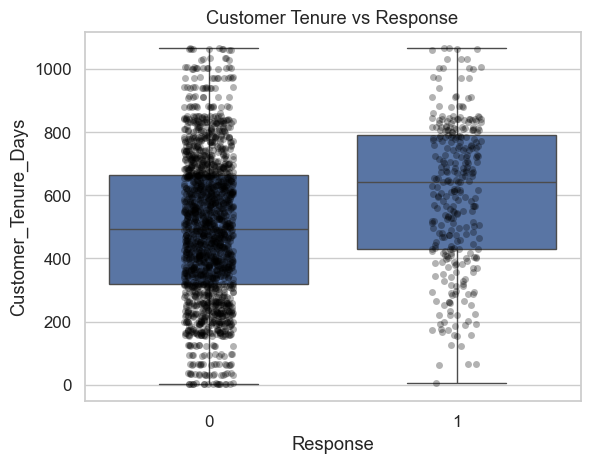

In [6]:
sns.boxplot(x='Response', y='Customer_Tenure_Days', data=df)
sns.stripplot(x='Response', y='Customer_Tenure_Days', data=df, color='black', alpha=0.3)
plt.title('Customer Tenure vs Response')
plt.show()

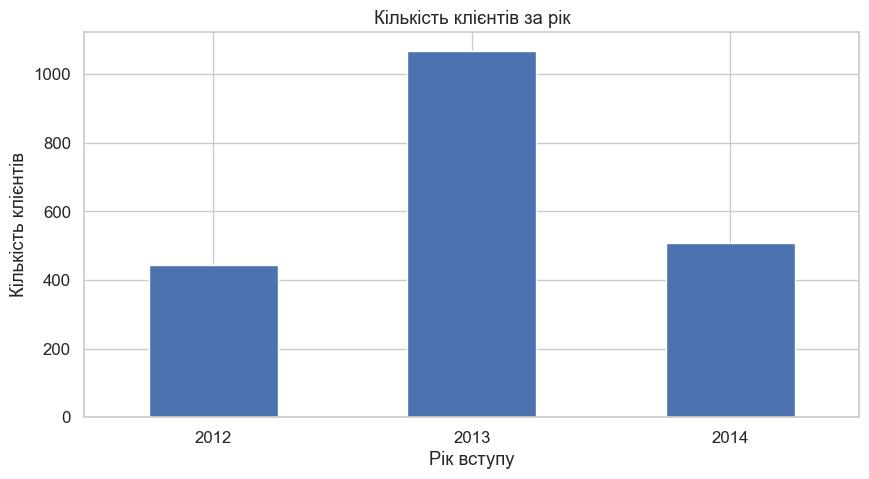

In [7]:
years_counts = df['Enroll_Year'].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(10,5))
years_counts.plot(kind='bar')
plt.title('Кількість клієнтів за рік')
plt.xlabel('Рік вступу')
plt.ylabel('Кількість клієнтів')
plt.xticks(rotation=0)
plt.show()

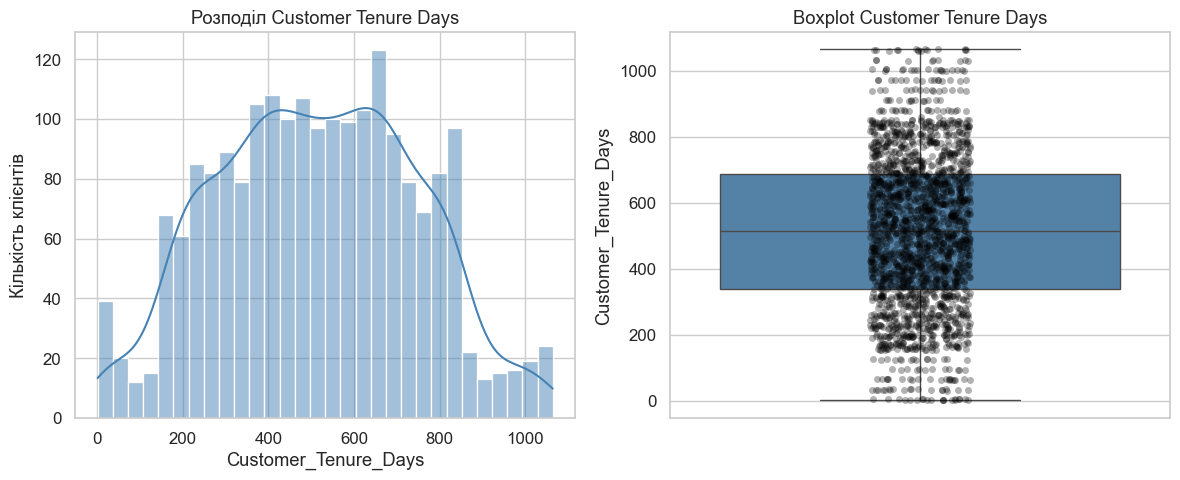

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['Customer_Tenure_Days'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Розподіл Customer Tenure Days')
axes[0].set_xlabel('Customer_Tenure_Days')
axes[0].set_ylabel('Кількість клієнтів')

sns.boxplot(y=df['Customer_Tenure_Days'], ax=axes[1], color='steelblue')
sns.stripplot(y=df['Customer_Tenure_Days'], ax=axes[1], color='black', alpha=0.3)
axes[1].set_title('Boxplot Customer Tenure Days')
axes[1].set_ylabel('Customer_Tenure_Days')

plt.tight_layout()
plt.show()

In [9]:
df = df.drop(columns=['Enroll_Year','Enroll_Month','Enroll_Quarter','Enrolled_H1'])
df

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age,Customer_Tenure_Days
0,1826,1970,Graduation,Divorced,84835.0000,0,0,2014-06-16,0,189,104,379,111,189,218,1,4,4,6,1,1,0,44,174
1,1,1961,Graduation,Single,57091.0000,0,0,2014-06-15,0,464,5,64,7,0,37,1,7,3,7,5,1,0,53,175
2,10476,1958,Graduation,Married,67267.0000,0,1,2014-05-13,0,134,11,59,15,2,30,1,3,2,5,2,0,0,56,208
3,1386,1967,Graduation,Together,32474.0000,1,1,2014-11-05,0,10,0,1,0,0,0,1,1,0,2,7,0,0,47,32
4,5371,1989,Graduation,Single,21474.0000,1,0,2014-08-04,0,6,16,24,11,0,34,2,3,1,2,7,1,0,25,125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018,10142,1976,PhD,Divorced,66476.0000,0,1,2013-07-03,99,372,18,126,47,48,78,2,5,2,11,4,0,0,38,522
2019,5263,1977,2n Cycle,Married,31056.0000,1,0,2013-01-22,99,5,10,13,3,8,16,1,1,0,3,8,0,0,37,684
2020,22,1976,Graduation,Divorced,46310.0000,1,0,2012-03-12,99,185,2,88,15,5,14,2,6,1,5,8,0,0,38,1000
2021,528,1978,Graduation,Married,65819.0000,0,0,2012-11-29,99,267,38,701,149,165,63,1,5,4,10,3,0,0,36,738


In [10]:
df.drop(columns=['NumWebVisitsMonth', 'NumDealsPurchases'], inplace=True)
# d≈0.00, p≈0.99 — повний шум, тільки зашумлюють модель

In [11]:
df

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Response,Complain,Age,Customer_Tenure_Days
0,1826,1970,Graduation,Divorced,84835.0000,0,0,2014-06-16,0,189,104,379,111,189,218,4,4,6,1,0,44,174
1,1,1961,Graduation,Single,57091.0000,0,0,2014-06-15,0,464,5,64,7,0,37,7,3,7,1,0,53,175
2,10476,1958,Graduation,Married,67267.0000,0,1,2014-05-13,0,134,11,59,15,2,30,3,2,5,0,0,56,208
3,1386,1967,Graduation,Together,32474.0000,1,1,2014-11-05,0,10,0,1,0,0,0,1,0,2,0,0,47,32
4,5371,1989,Graduation,Single,21474.0000,1,0,2014-08-04,0,6,16,24,11,0,34,3,1,2,1,0,25,125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018,10142,1976,PhD,Divorced,66476.0000,0,1,2013-07-03,99,372,18,126,47,48,78,5,2,11,0,0,38,522
2019,5263,1977,2n Cycle,Married,31056.0000,1,0,2013-01-22,99,5,10,13,3,8,16,1,0,3,0,0,37,684
2020,22,1976,Graduation,Divorced,46310.0000,1,0,2012-03-12,99,185,2,88,15,5,14,6,1,5,0,0,38,1000
2021,528,1978,Graduation,Married,65819.0000,0,0,2012-11-29,99,267,38,701,149,165,63,5,4,10,0,0,36,738


In [12]:
# Age (d=-0.06) та NumStorePurchases (d=0.09) — слабкі
# Але дешево тримати, якщо використовуєш дерева (вони самі ігнорують)
# Для лінійних моделей — краще дропнути
df.drop(columns=['Year_Birth'], inplace=True)

In [13]:
from scipy.stats import skew
skewed_cols = [
    'MntWines', 'MntMeatProducts', 'MntFruits',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumCatalogPurchases', 'NumWebPurchases', 'Income'
]
for col in skewed_cols:
    print(f"{col} skew: {skew(df[col].dropna()):.2f}")

MntWines skew: 1.17
MntMeatProducts skew: 2.04
MntFruits skew: 2.11
MntFishProducts skew: 1.93
MntSweetProducts skew: 2.11
MntGoldProds skew: 1.85
NumCatalogPurchases skew: 1.95
NumWebPurchases skew: 1.23
Income skew: 0.37


In [14]:
skewed_cols = [
    'MntWines', 'MntMeatProducts', 'MntFruits',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumCatalogPurchases', 'NumWebPurchases'
]

for col in skewed_cols:
    df[f'{col}_log'] = np.log1p(df[col])

In [15]:
df

,Id,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Response,Complain,Age,Customer_Tenure_Days,MntWines_log,MntMeatProducts_log,MntFruits_log,MntFishProducts_log,MntSweetProducts_log,MntGoldProds_log,NumCatalogPurchases_log,NumWebPurchases_log
0,1826,Graduation,Divorced,84835.0000,0,0,2014-06-16,0,189,104,379,111,189,218,4,4,6,1,0,44,174,5.2470,5.9402,4.6540,4.7185,5.2470,5.3891,1.6094,1.6094
1,1,Graduation,Single,57091.0000,0,0,2014-06-15,0,464,5,64,7,0,37,7,3,7,1,0,53,175,6.1420,4.1744,1.7918,2.0794,0.0000,3.6376,1.3863,2.0794
2,10476,Graduation,Married,67267.0000,0,1,2014-05-13,0,134,11,59,15,2,30,3,2,5,0,0,56,208,4.9053,4.0943,2.4849,2.7726,1.0986,3.4340,1.0986,1.3863
3,1386,Graduation,Together,32474.0000,1,1,2014-11-05,0,10,0,1,0,0,0,1,0,2,0,0,47,32,2.3979,0.6931,0.0000,0.0000,0.0000,0.0000,0.0000,0.6931
4,5371,Graduation,Single,21474.0000,1,0,2014-08-04,0,6,16,24,11,0,34,3,1,2,1,0,25,125,1.9459,3.2189,2.8332,2.4849,0.0000,3.5553,0.6931,1.3863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018,10142,PhD,Divorced,66476.0000,0,1,2013-07-03,99,372,18,126,47,48,78,5,2,11,0,0,38,522,5.9216,4.8442,2.9444,3.8712,3.8918,4.3694,1.0986,1.7918
2019,5263,2n Cycle,Married,31056.0000,1,0,2013-01-22,99,5,10,13,3,8,16,1,0,3,0,0,37,684,1.7918,2.6391,2.3979,1.3863,2.1972,2.8332,0.0000,0.6931
2020,22,Graduation,Divorced,46310.0000,1,0,2012-03-12,99,185,2,88,15,5,14,6,1,5,0,0,38,1000,5.2257,4.4886,1.0986,2.7726,1.7918,2.7081,0.6931,1.9459
2021,528,Graduation,Married,65819.0000,0,0,2012-11-29,99,267,38,701,149,165,63,5,4,10,0,0,36,738,5.5910,6.5539,3.6636,5.0106,5.1120,4.1589,1.6094,1.7918


In [16]:
mnt_cols = ['MntWines', 'MntMeatProducts', 'MntFruits',
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

df['TotalMnt'] = df[mnt_cols].sum(axis=1)
df['TotalPurchases'] = df[['NumWebPurchases', 
                            'NumCatalogPurchases', 
                            'NumStorePurchases']].sum(axis=1)

In [17]:
# Скільки % доходу витрачає на преміум товари
df['WineRatio'] = df['MntWines'] / (df['Income'] + 1)
df['MeatRatio'] = df['MntMeatProducts'] / (df['Income'] + 1)
df['PremiumRatio'] = (df['MntWines'] + df['MntMeatProducts']) / (df['TotalMnt'] + 1)

In [18]:
df['CatalogShare'] = df['NumCatalogPurchases'] / (df['TotalPurchases'] + 1)
# Топ фіча — якщо висока частка = лояльний клієнт

In [19]:
df

,Id,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Response,Complain,Age,Customer_Tenure_Days,MntWines_log,MntMeatProducts_log,MntFruits_log,MntFishProducts_log,MntSweetProducts_log,MntGoldProds_log,NumCatalogPurchases_log,NumWebPurchases_log,TotalMnt,TotalPurchases,WineRatio,MeatRatio,PremiumRatio,CatalogShare
0,1826,Graduation,Divorced,84835.0000,0,0,2014-06-16,0,189,104,379,111,189,218,4,4,6,1,0,44,174,5.2470,5.9402,4.6540,4.7185,5.2470,5.3891,1.6094,1.6094,1190,14,0.0022,0.0045,0.4769,0.2667
1,1,Graduation,Single,57091.0000,0,0,2014-06-15,0,464,5,64,7,0,37,7,3,7,1,0,53,175,6.1420,4.1744,1.7918,2.0794,0.0000,3.6376,1.3863,2.0794,577,17,0.0081,0.0011,0.9135,0.1667
2,10476,Graduation,Married,67267.0000,0,1,2014-05-13,0,134,11,59,15,2,30,3,2,5,0,0,56,208,4.9053,4.0943,2.4849,2.7726,1.0986,3.4340,1.0986,1.3863,251,10,0.0020,0.0009,0.7659,0.1818
3,1386,Graduation,Together,32474.0000,1,1,2014-11-05,0,10,0,1,0,0,0,1,0,2,0,0,47,32,2.3979,0.6931,0.0000,0.0000,0.0000,0.0000,0.0000,0.6931,11,3,0.0003,0.0000,0.9167,0.0000
4,5371,Graduation,Single,21474.0000,1,0,2014-08-04,0,6,16,24,11,0,34,3,1,2,1,0,25,125,1.9459,3.2189,2.8332,2.4849,0.0000,3.5553,0.6931,1.3863,91,6,0.0003,0.0011,0.3261,0.1429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018,10142,PhD,Divorced,66476.0000,0,1,2013-07-03,99,372,18,126,47,48,78,5,2,11,0,0,38,522,5.9216,4.8442,2.9444,3.8712,3.8918,4.3694,1.0986,1.7918,689,18,0.0056,0.0019,0.7217,0.1053
2019,5263,2n Cycle,Married,31056.0000,1,0,2013-01-22,99,5,10,13,3,8,16,1,0,3,0,0,37,684,1.7918,2.6391,2.3979,1.3863,2.1972,2.8332,0.0000,0.6931,55,4,0.0002,0.0004,0.3214,0.0000
2020,22,Graduation,Divorced,46310.0000,1,0,2012-03-12,99,185,2,88,15,5,14,6,1,5,0,0,38,1000,5.2257,4.4886,1.0986,2.7726,1.7918,2.7081,0.6931,1.9459,309,12,0.0040,0.0019,0.8806,0.0769
2021,528,Graduation,Married,65819.0000,0,0,2012-11-29,99,267,38,701,149,165,63,5,4,10,0,0,36,738,5.5910,6.5539,3.6636,5.0106,5.1120,4.1589,1.6094,1.7918,1383,19,0.0041,0.0107,0.6994,0.2000


In [20]:
drop_cols = [
    'MntWines',
    'MntMeatProducts', 
    'MntFruits',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumCatalogPurchases',
    'NumWebPurchases',
    'Dt_Customer'
]

df.drop(columns=drop_cols, inplace=True)

In [21]:
df

,Id,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,NumStorePurchases,Response,Complain,Age,Customer_Tenure_Days,MntWines_log,MntMeatProducts_log,MntFruits_log,MntFishProducts_log,MntSweetProducts_log,MntGoldProds_log,NumCatalogPurchases_log,NumWebPurchases_log,TotalMnt,TotalPurchases,WineRatio,MeatRatio,PremiumRatio,CatalogShare
0,1826,Graduation,Divorced,84835.0000,0,0,0,6,1,0,44,174,5.2470,5.9402,4.6540,4.7185,5.2470,5.3891,1.6094,1.6094,1190,14,0.0022,0.0045,0.4769,0.2667
1,1,Graduation,Single,57091.0000,0,0,0,7,1,0,53,175,6.1420,4.1744,1.7918,2.0794,0.0000,3.6376,1.3863,2.0794,577,17,0.0081,0.0011,0.9135,0.1667
2,10476,Graduation,Married,67267.0000,0,1,0,5,0,0,56,208,4.9053,4.0943,2.4849,2.7726,1.0986,3.4340,1.0986,1.3863,251,10,0.0020,0.0009,0.7659,0.1818
3,1386,Graduation,Together,32474.0000,1,1,0,2,0,0,47,32,2.3979,0.6931,0.0000,0.0000,0.0000,0.0000,0.0000,0.6931,11,3,0.0003,0.0000,0.9167,0.0000
4,5371,Graduation,Single,21474.0000,1,0,0,2,1,0,25,125,1.9459,3.2189,2.8332,2.4849,0.0000,3.5553,0.6931,1.3863,91,6,0.0003,0.0011,0.3261,0.1429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018,10142,PhD,Divorced,66476.0000,0,1,99,11,0,0,38,522,5.9216,4.8442,2.9444,3.8712,3.8918,4.3694,1.0986,1.7918,689,18,0.0056,0.0019,0.7217,0.1053
2019,5263,2n Cycle,Married,31056.0000,1,0,99,3,0,0,37,684,1.7918,2.6391,2.3979,1.3863,2.1972,2.8332,0.0000,0.6931,55,4,0.0002,0.0004,0.3214,0.0000
2020,22,Graduation,Divorced,46310.0000,1,0,99,5,0,0,38,1000,5.2257,4.4886,1.0986,2.7726,1.7918,2.7081,0.6931,1.9459,309,12,0.0040,0.0019,0.8806,0.0769
2021,528,Graduation,Married,65819.0000,0,0,99,10,0,0,36,738,5.5910,6.5539,3.6636,5.0106,5.1120,4.1589,1.6094,1.7918,1383,19,0.0041,0.0107,0.6994,0.2000


In [22]:
print(df.columns.tolist())

['Id', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'NumStorePurchases', 'Response', 'Complain', 'Age', 'Customer_Tenure_Days', 'MntWines_log', 'MntMeatProducts_log', 'MntFruits_log', 'MntFishProducts_log', 'MntSweetProducts_log', 'MntGoldProds_log', 'NumCatalogPurchases_log', 'NumWebPurchases_log', 'TotalMnt', 'TotalPurchases', 'WineRatio', 'MeatRatio', 'PremiumRatio', 'CatalogShare']


In [23]:
df.drop(columns=['Complain'], inplace=True)

In [24]:
# Підозрілі пари — можуть сильно корелювати:
suspect_pairs = [
    ('TotalMnt', 'MntWines_log'),
    ('TotalMnt', 'PremiumRatio'),
    ('CatalogShare', 'NumCatalogPurchases_log'),
    ('WineRatio', 'MntWines_log'),
]

for col1, col2 in suspect_pairs:
    c = df[col1].corr(df[col2])
    print(f"{col1} vs {col2}: {c:.3f}")

TotalMnt vs MntWines_log: 0.803
TotalMnt vs PremiumRatio: 0.368
CatalogShare vs NumCatalogPurchases_log: 0.917
WineRatio vs MntWines_log: 0.833


In [25]:
drop_cols = [
    'MntWines_log',              
    'NumCatalogPurchases_log'
]

#df.drop(columns=drop_cols, inplace=True)

In [26]:
df

,Id,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,NumStorePurchases,Response,Age,Customer_Tenure_Days,MntWines_log,MntMeatProducts_log,MntFruits_log,MntFishProducts_log,MntSweetProducts_log,MntGoldProds_log,NumCatalogPurchases_log,NumWebPurchases_log,TotalMnt,TotalPurchases,WineRatio,MeatRatio,PremiumRatio,CatalogShare
0,1826,Graduation,Divorced,84835.0000,0,0,0,6,1,44,174,5.2470,5.9402,4.6540,4.7185,5.2470,5.3891,1.6094,1.6094,1190,14,0.0022,0.0045,0.4769,0.2667
1,1,Graduation,Single,57091.0000,0,0,0,7,1,53,175,6.1420,4.1744,1.7918,2.0794,0.0000,3.6376,1.3863,2.0794,577,17,0.0081,0.0011,0.9135,0.1667
2,10476,Graduation,Married,67267.0000,0,1,0,5,0,56,208,4.9053,4.0943,2.4849,2.7726,1.0986,3.4340,1.0986,1.3863,251,10,0.0020,0.0009,0.7659,0.1818
3,1386,Graduation,Together,32474.0000,1,1,0,2,0,47,32,2.3979,0.6931,0.0000,0.0000,0.0000,0.0000,0.0000,0.6931,11,3,0.0003,0.0000,0.9167,0.0000
4,5371,Graduation,Single,21474.0000,1,0,0,2,1,25,125,1.9459,3.2189,2.8332,2.4849,0.0000,3.5553,0.6931,1.3863,91,6,0.0003,0.0011,0.3261,0.1429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018,10142,PhD,Divorced,66476.0000,0,1,99,11,0,38,522,5.9216,4.8442,2.9444,3.8712,3.8918,4.3694,1.0986,1.7918,689,18,0.0056,0.0019,0.7217,0.1053
2019,5263,2n Cycle,Married,31056.0000,1,0,99,3,0,37,684,1.7918,2.6391,2.3979,1.3863,2.1972,2.8332,0.0000,0.6931,55,4,0.0002,0.0004,0.3214,0.0000
2020,22,Graduation,Divorced,46310.0000,1,0,99,5,0,38,1000,5.2257,4.4886,1.0986,2.7726,1.7918,2.7081,0.6931,1.9459,309,12,0.0040,0.0019,0.8806,0.0769
2021,528,Graduation,Married,65819.0000,0,0,99,10,0,36,738,5.5910,6.5539,3.6636,5.0106,5.1120,4.1589,1.6094,1.7918,1383,19,0.0041,0.0107,0.6994,0.2000


### Кодування категорійних змінних

In [27]:
edu_order = {'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}
df['Education'] = df['Education'].map(edu_order)

In [28]:
df['is_alone'] = df['Marital_Status'].isin(
    ['Single', 'Widow', 'Divorced']
).astype(int)

In [29]:
df

,Id,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,NumStorePurchases,Response,Age,Customer_Tenure_Days,MntWines_log,MntMeatProducts_log,MntFruits_log,MntFishProducts_log,MntSweetProducts_log,MntGoldProds_log,NumCatalogPurchases_log,NumWebPurchases_log,TotalMnt,TotalPurchases,WineRatio,MeatRatio,PremiumRatio,CatalogShare,is_alone
0,1826,2,Divorced,84835.0000,0,0,0,6,1,44,174,5.2470,5.9402,4.6540,4.7185,5.2470,5.3891,1.6094,1.6094,1190,14,0.0022,0.0045,0.4769,0.2667,1
1,1,2,Single,57091.0000,0,0,0,7,1,53,175,6.1420,4.1744,1.7918,2.0794,0.0000,3.6376,1.3863,2.0794,577,17,0.0081,0.0011,0.9135,0.1667,1
2,10476,2,Married,67267.0000,0,1,0,5,0,56,208,4.9053,4.0943,2.4849,2.7726,1.0986,3.4340,1.0986,1.3863,251,10,0.0020,0.0009,0.7659,0.1818,0
3,1386,2,Together,32474.0000,1,1,0,2,0,47,32,2.3979,0.6931,0.0000,0.0000,0.0000,0.0000,0.0000,0.6931,11,3,0.0003,0.0000,0.9167,0.0000,0
4,5371,2,Single,21474.0000,1,0,0,2,1,25,125,1.9459,3.2189,2.8332,2.4849,0.0000,3.5553,0.6931,1.3863,91,6,0.0003,0.0011,0.3261,0.1429,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018,10142,4,Divorced,66476.0000,0,1,99,11,0,38,522,5.9216,4.8442,2.9444,3.8712,3.8918,4.3694,1.0986,1.7918,689,18,0.0056,0.0019,0.7217,0.1053,1
2019,5263,1,Married,31056.0000,1,0,99,3,0,37,684,1.7918,2.6391,2.3979,1.3863,2.1972,2.8332,0.0000,0.6931,55,4,0.0002,0.0004,0.3214,0.0000,0
2020,22,2,Divorced,46310.0000,1,0,99,5,0,38,1000,5.2257,4.4886,1.0986,2.7726,1.7918,2.7081,0.6931,1.9459,309,12,0.0040,0.0019,0.8806,0.0769,1
2021,528,2,Married,65819.0000,0,0,99,10,0,36,738,5.5910,6.5539,3.6636,5.0106,5.1120,4.1589,1.6094,1.7918,1383,19,0.0041,0.0107,0.6994,0.2000,0


In [30]:
df.drop(columns=['Marital_Status'], inplace=True)

In [31]:
df

,Id,Education,Income,Kidhome,Teenhome,Recency,NumStorePurchases,Response,Age,Customer_Tenure_Days,MntWines_log,MntMeatProducts_log,MntFruits_log,MntFishProducts_log,MntSweetProducts_log,MntGoldProds_log,NumCatalogPurchases_log,NumWebPurchases_log,TotalMnt,TotalPurchases,WineRatio,MeatRatio,PremiumRatio,CatalogShare,is_alone
0,1826,2,84835.0000,0,0,0,6,1,44,174,5.2470,5.9402,4.6540,4.7185,5.2470,5.3891,1.6094,1.6094,1190,14,0.0022,0.0045,0.4769,0.2667,1
1,1,2,57091.0000,0,0,0,7,1,53,175,6.1420,4.1744,1.7918,2.0794,0.0000,3.6376,1.3863,2.0794,577,17,0.0081,0.0011,0.9135,0.1667,1
2,10476,2,67267.0000,0,1,0,5,0,56,208,4.9053,4.0943,2.4849,2.7726,1.0986,3.4340,1.0986,1.3863,251,10,0.0020,0.0009,0.7659,0.1818,0
3,1386,2,32474.0000,1,1,0,2,0,47,32,2.3979,0.6931,0.0000,0.0000,0.0000,0.0000,0.0000,0.6931,11,3,0.0003,0.0000,0.9167,0.0000,0
4,5371,2,21474.0000,1,0,0,2,1,25,125,1.9459,3.2189,2.8332,2.4849,0.0000,3.5553,0.6931,1.3863,91,6,0.0003,0.0011,0.3261,0.1429,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018,10142,4,66476.0000,0,1,99,11,0,38,522,5.9216,4.8442,2.9444,3.8712,3.8918,4.3694,1.0986,1.7918,689,18,0.0056,0.0019,0.7217,0.1053,1
2019,5263,1,31056.0000,1,0,99,3,0,37,684,1.7918,2.6391,2.3979,1.3863,2.1972,2.8332,0.0000,0.6931,55,4,0.0002,0.0004,0.3214,0.0000,0
2020,22,2,46310.0000,1,0,99,5,0,38,1000,5.2257,4.4886,1.0986,2.7726,1.7918,2.7081,0.6931,1.9459,309,12,0.0040,0.0019,0.8806,0.0769,1
2021,528,2,65819.0000,0,0,99,10,0,36,738,5.5910,6.5539,3.6636,5.0106,5.1120,4.1589,1.6094,1.7918,1383,19,0.0041,0.0107,0.6994,0.2000,0


In [32]:
from scipy.stats import spearmanr, pointbiserialr
import pandas as pd
import numpy as np

# Розділи фічі за типом
binary_cols = ['is_alone'] + [c for c in df.columns if 'Marital_Status_' in c]
ordinal_cols = ['Education', 'Kidhome', 'Teenhome']
continuous_cols = [
    'Income', 'Recency', 'Age', 'Customer_Tenure_Days',
    'MntMeatProducts_log', 'MntFruits_log', 'MntFishProducts_log',
    'MntSweetProducts_log', 'MntGoldProds_log', 'NumWebPurchases_log',
    'TotalMnt', 'TotalPurchases', 'WineRatio', 'MeatRatio',
    'PremiumRatio', 'CatalogShare'
]

# Кореляція з таргетом — правильно
results = []

# Неперервні → Pearson
for col in continuous_cols:
    c = df[col].corr(df['Response'])
    results.append({'feature': col, 'correlation': c, 'method': 'Pearson'})

# Порядкові → Spearman  
for col in ordinal_cols:
    c, p = spearmanr(df[col], df['Response'])
    results.append({'feature': col, 'correlation': c, 'method': 'Spearman'})

# Бінарні → Point-Biserial (= Pearson для 0/1)
for col in binary_cols:
    c = df[col].corr(df['Response'])
    results.append({'feature': col, 'correlation': c, 'method': 'Point-Biserial'})

corr_df = pd.DataFrame(results).sort_values('correlation', ascending=False)
print(corr_df)

                 feature  correlation          method
10              TotalMnt       0.2633         Pearson
15          CatalogShare       0.2444         Pearson
4    MntMeatProducts_log       0.2226         Pearson
12             WineRatio       0.2095         Pearson
8       MntGoldProds_log       0.1846         Pearson
3   Customer_Tenure_Days       0.1726         Pearson
9    NumWebPurchases_log       0.1695         Pearson
11        TotalPurchases       0.1610         Pearson
0                 Income       0.1606         Pearson
5          MntFruits_log       0.1479         Pearson
19              is_alone       0.1479  Point-Biserial
7   MntSweetProducts_log       0.1361         Pearson
6    MntFishProducts_log       0.1094         Pearson
16             Education       0.0863        Spearman
14          PremiumRatio       0.0544         Pearson
13             MeatRatio       0.0333         Pearson
2                    Age      -0.0227         Pearson
17               Kidhome    

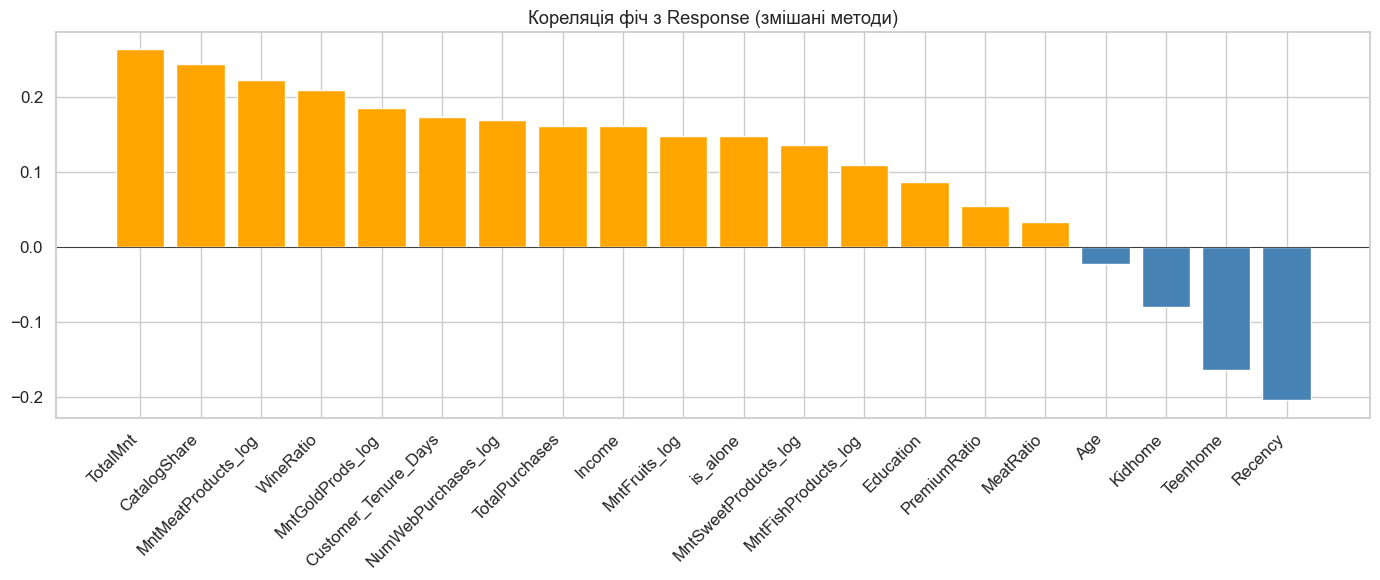

In [33]:
import matplotlib.pyplot as plt

colors = corr_df['correlation'].apply(lambda x: 'orange' if x > 0 else 'steelblue')

plt.figure(figsize=(14, 6))
plt.bar(corr_df['feature'], corr_df['correlation'], color=colors)
plt.axhline(0, color='black', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.title('Кореляція фіч з Response (змішані методи)')
plt.tight_layout()
plt.show()

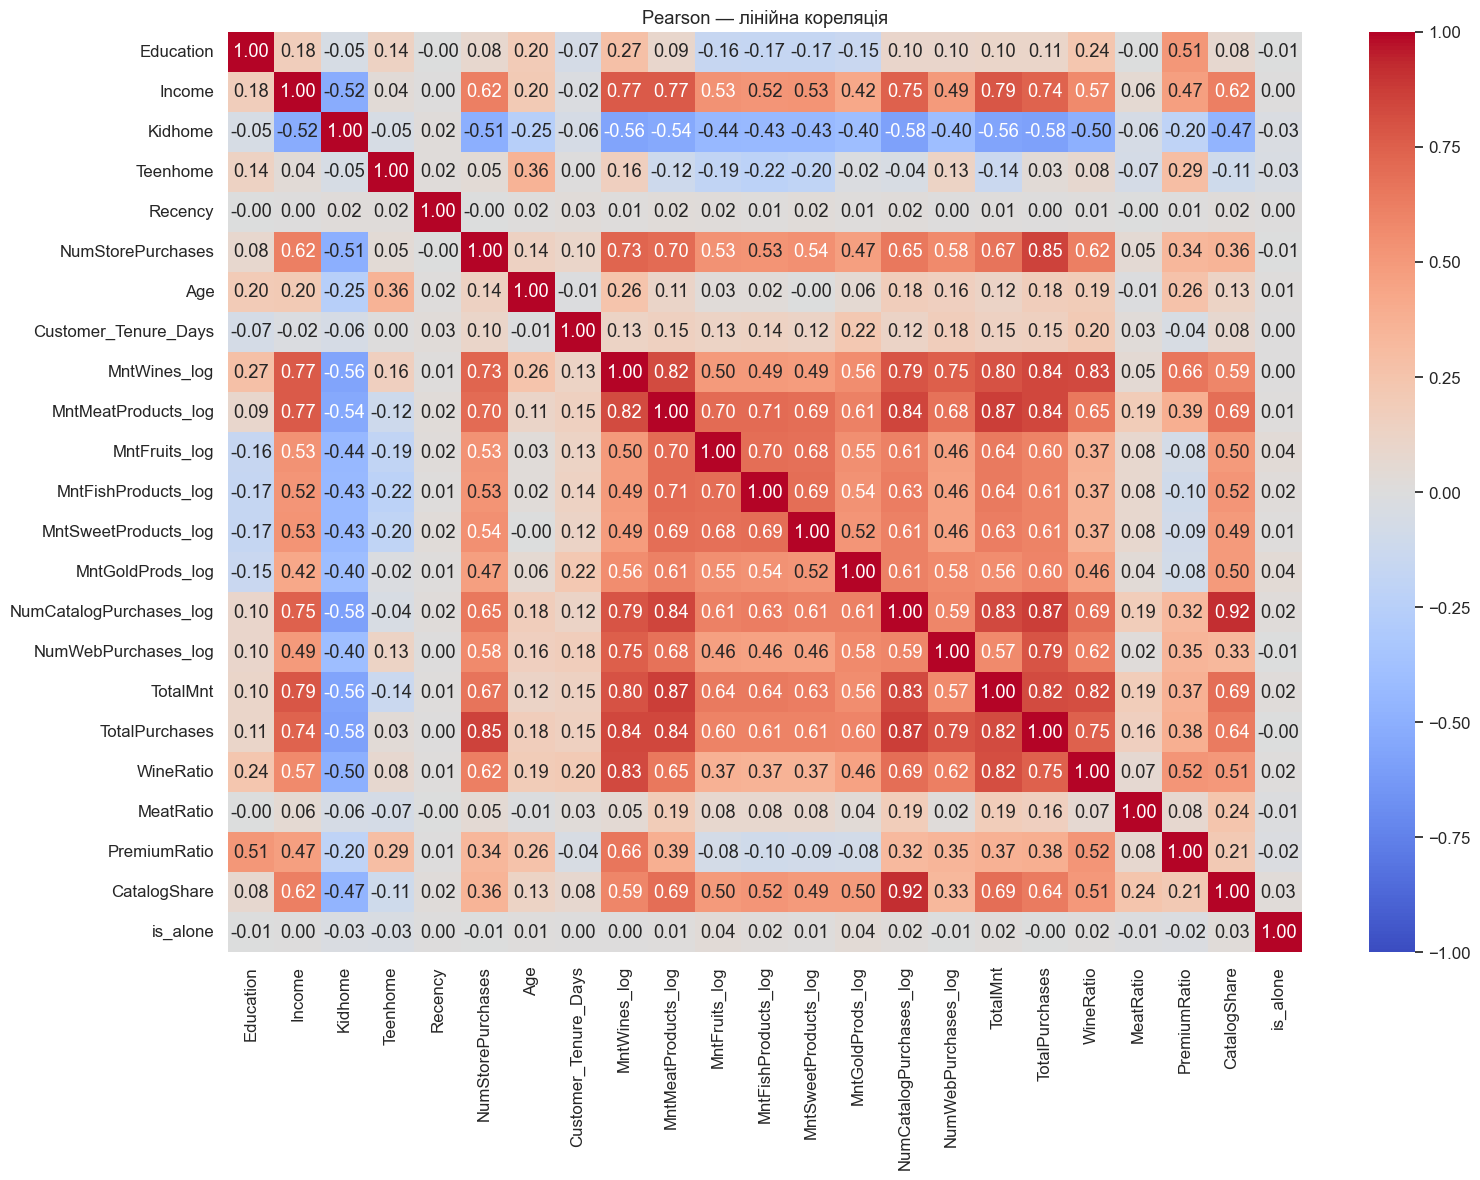

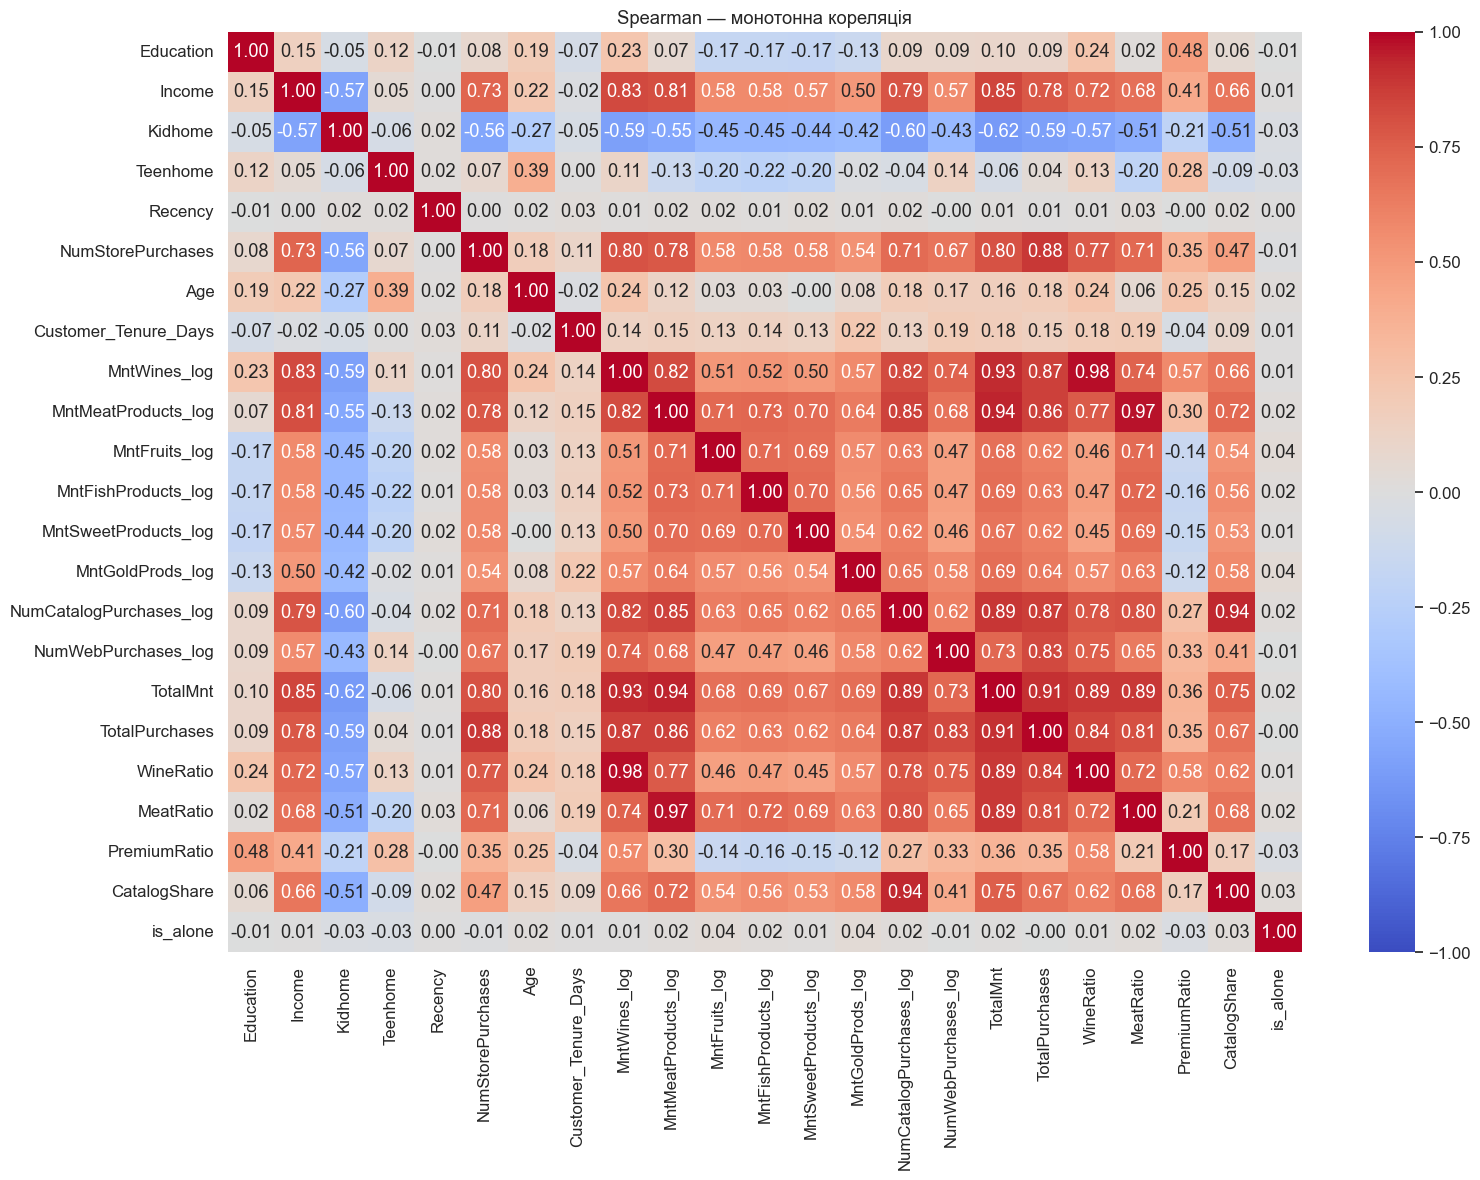

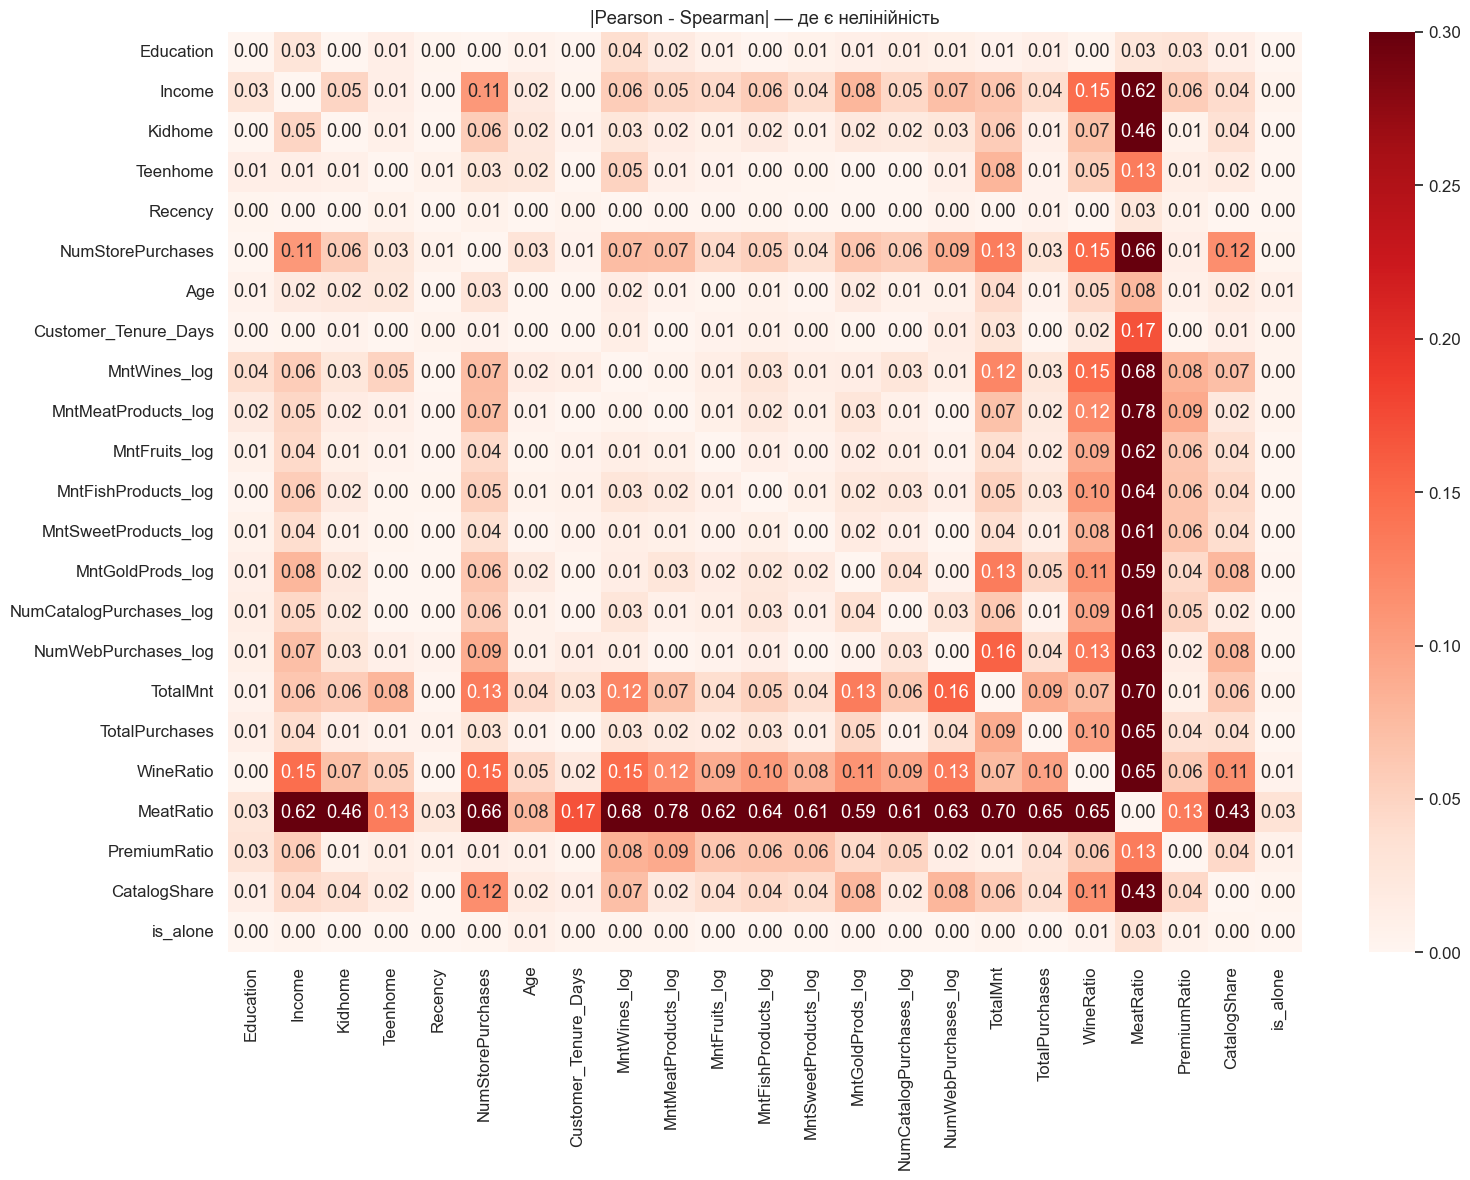

=== Pearson пари > 0.70 ===
                  feature_1                feature_2  correlation   method
21  NumCatalogPurchases_log             CatalogShare       0.9170  Pearson
17      MntMeatProducts_log                 TotalMnt       0.8710  Pearson
20  NumCatalogPurchases_log           TotalPurchases       0.8680  Pearson
7         NumStorePurchases           TotalPurchases       0.8550  Pearson
16      MntMeatProducts_log  NumCatalogPurchases_log       0.8440  Pearson
18      MntMeatProducts_log           TotalPurchases       0.8420  Pearson
12             MntWines_log           TotalPurchases       0.8400  Pearson
13             MntWines_log                WineRatio       0.8330  Pearson
19  NumCatalogPurchases_log                 TotalMnt       0.8320  Pearson
8              MntWines_log      MntMeatProducts_log       0.8240  Pearson
23                 TotalMnt           TotalPurchases       0.8210  Pearson
24                 TotalMnt                WineRatio       0.8160  Pears

In [34]:
from scipy.stats import spearmanr



def get_top_corr_pairs(corr_matrix, threshold=0.70, method='Pearson'):
    pairs = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            val = corr_matrix.iloc[i, j]
            if abs(val) >= threshold:
                pairs.append({
                    'feature_1': cols[i],
                    'feature_2': cols[j],
                    'correlation': round(val, 3),
                    'method': method
                })
    return pd.DataFrame(pairs).sort_values('correlation', 
                                            key=abs, 
                                            ascending=False)


features = df.drop(columns=['Id', 'Response']).select_dtypes(include='number')
pearson_corr = features.corr(method='pearson')

plt.figure(figsize=(16, 12))
sns.heatmap(pearson_corr, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Pearson — лінійна кореляція')
plt.tight_layout()
plt.show()

spearman_corr = features.corr(method='spearman')

plt.figure(figsize=(16, 12))
sns.heatmap(spearman_corr, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Spearman — монотонна кореляція')
plt.tight_layout()
plt.show()

diff = (pearson_corr - spearman_corr).abs()

plt.figure(figsize=(16, 12))
sns.heatmap(diff, annot=True, fmt='.2f',
            cmap='Reds', vmin=0, vmax=0.3)
plt.title('|Pearson - Spearman| — де є нелінійність')
plt.tight_layout()
plt.show()

print("=== Pearson пари > 0.70 ===")
print(get_top_corr_pairs(pearson_corr, threshold=0.70, method='Pearson'))

print("\n=== Spearman пари > 0.70 ===")
print(get_top_corr_pairs(spearman_corr, threshold=0.70, method='Spearman'))

In [35]:
drop_cols = [
    # TotalMnt vs MntMeatProducts_log = 0.87/0.94 — дублювання
    'MntMeatProducts_log',    # поглинається TotalMnt + MeatRatio
    
    # TotalPurchases vs NumStorePurchases = 0.85/0.88 — дублювання  
    'NumStorePurchases',      # поглинається TotalPurchases
    
    # MeatRatio vs MntMeatProducts_log = 0.97 (Spearman!) — майже копія
    'MeatRatio',              # MntMeatProducts_log вже дропнули, але й MeatRatio слабка по таргету (~0.03)
    
    # WineRatio vs TotalPurchases = 0.84 + слабша за WineRatio окремо
    # TotalMnt vs TotalPurchases = 0.82/0.91 — дуже схожі
    'TotalPurchases',         # TotalMnt сильніший по таргету (0.26 vs 0.16)
    'Age'
]

#df.drop(columns=drop_cols, inplace=True)
df

,Id,Education,Income,Kidhome,Teenhome,Recency,NumStorePurchases,Response,Age,Customer_Tenure_Days,MntWines_log,MntMeatProducts_log,MntFruits_log,MntFishProducts_log,MntSweetProducts_log,MntGoldProds_log,NumCatalogPurchases_log,NumWebPurchases_log,TotalMnt,TotalPurchases,WineRatio,MeatRatio,PremiumRatio,CatalogShare,is_alone
0,1826,2,84835.0000,0,0,0,6,1,44,174,5.2470,5.9402,4.6540,4.7185,5.2470,5.3891,1.6094,1.6094,1190,14,0.0022,0.0045,0.4769,0.2667,1
1,1,2,57091.0000,0,0,0,7,1,53,175,6.1420,4.1744,1.7918,2.0794,0.0000,3.6376,1.3863,2.0794,577,17,0.0081,0.0011,0.9135,0.1667,1
2,10476,2,67267.0000,0,1,0,5,0,56,208,4.9053,4.0943,2.4849,2.7726,1.0986,3.4340,1.0986,1.3863,251,10,0.0020,0.0009,0.7659,0.1818,0
3,1386,2,32474.0000,1,1,0,2,0,47,32,2.3979,0.6931,0.0000,0.0000,0.0000,0.0000,0.0000,0.6931,11,3,0.0003,0.0000,0.9167,0.0000,0
4,5371,2,21474.0000,1,0,0,2,1,25,125,1.9459,3.2189,2.8332,2.4849,0.0000,3.5553,0.6931,1.3863,91,6,0.0003,0.0011,0.3261,0.1429,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018,10142,4,66476.0000,0,1,99,11,0,38,522,5.9216,4.8442,2.9444,3.8712,3.8918,4.3694,1.0986,1.7918,689,18,0.0056,0.0019,0.7217,0.1053,1
2019,5263,1,31056.0000,1,0,99,3,0,37,684,1.7918,2.6391,2.3979,1.3863,2.1972,2.8332,0.0000,0.6931,55,4,0.0002,0.0004,0.3214,0.0000,0
2020,22,2,46310.0000,1,0,99,5,0,38,1000,5.2257,4.4886,1.0986,2.7726,1.7918,2.7081,0.6931,1.9459,309,12,0.0040,0.0019,0.8806,0.0769,1
2021,528,2,65819.0000,0,0,99,10,0,36,738,5.5910,6.5539,3.6636,5.0106,5.1120,4.1589,1.6094,1.7918,1383,19,0.0041,0.0107,0.6994,0.2000,0


In [36]:
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, train_test_split
)
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    classification_report, roc_auc_score,
    average_precision_score, confusion_matrix,
    make_scorer, f1_score, precision_score, recall_score
)
from sklearn.inspection import permutation_importance

# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline


TARGET = "Response"
DROP_COLS = ["Id", TARGET]

FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]

X = df[FEATURE_COLS].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y      
)

In [37]:
X_train

,Education,Income,Kidhome,Teenhome,Recency,NumStorePurchases,Age,Customer_Tenure_Days,MntWines_log,MntMeatProducts_log,MntFruits_log,MntFishProducts_log,MntSweetProducts_log,MntGoldProds_log,NumCatalogPurchases_log,NumWebPurchases_log,TotalMnt,TotalPurchases,WineRatio,MeatRatio,PremiumRatio,CatalogShare,is_alone
1308,3,54730.0000,0,1,64,8,39,479,5.7652,2.8904,1.3863,1.6094,2.0794,4.0431,0.6931,1.6094,405,13,0.0058,0.0003,0.8251,0.0714,0
1279,2,56775.0000,0,1,62,10,35,674,6.4216,5.0814,3.5835,4.0775,3.5835,3.5835,2.1972,1.7918,937,23,0.0108,0.0028,0.8252,0.3333,0
1435,2,49638.0000,0,1,71,3,62,232,2.9444,1.3863,2.3979,1.3863,1.7918,0.0000,0.0000,0.6931,39,4,0.0004,0.0001,0.5250,0.0000,1
1848,4,27683.0000,1,0,90,4,36,973,5.0304,4.8040,2.3026,2.5649,2.5649,3.8286,1.0986,1.9459,351,12,0.0055,0.0044,0.7756,0.1538,0
779,4,40706.0000,2,1,37,4,46,689,4.0943,2.4849,0.0000,1.6094,1.0986,1.7918,0.0000,1.3863,81,7,0.0014,0.0003,0.8537,0.0000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,3,75345.0000,0,0,16,6,44,673,6.8233,6.7370,4.0604,4.6052,3.6636,4.8978,2.1972,1.7918,2087,19,0.0122,0.0112,0.8429,0.4000,1
477,2,40049.0000,0,1,23,3,62,417,2.6391,2.0794,1.9459,0.0000,1.3863,1.3863,0.0000,0.6931,32,4,0.0003,0.0002,0.6061,0.0000,1
611,2,70666.0000,0,0,29,4,66,543,5.9890,5.9081,3.7136,4.7875,4.8122,3.4340,1.6094,2.0794,1076,15,0.0056,0.0052,0.7103,0.2500,0
1581,2,18690.0000,0,0,77,2,55,709,1.9459,2.0794,0.6931,3.1781,1.6094,2.9957,0.6931,0.6931,60,4,0.0003,0.0004,0.2131,0.2000,0


In [38]:
# Логарифмовані → StandardScaler або без масштабування
log_features = [
    'MntFruits_log',
    'MntFishProducts_log',
    'MntSweetProducts_log',
    'MntGoldProds_log',
    'NumWebPurchases_log',
]

# Сирі числові → RobustScaler
raw_features = [
    'Income',
    'Recency',
    'Customer_Tenure_Days',
    'TotalMnt',
    'WineRatio',
    'PremiumRatio',
    'CatalogShare',
]

# Бінарні / порядкові → без змін
passthrough_features = [
    'Education',
    'Kidhome',
    'Teenhome',
    'is_alone',
]

In [39]:
smote = SMOTE(
    random_state=42
)

log_features = [
    'MntWines_log',
    'MntMeatProducts_log',
    'MntFruits_log',
    'MntFishProducts_log',
    'MntSweetProducts_log',
    'MntGoldProds_log',
    'NumCatalogPurchases_log',
    'NumWebPurchases_log',
]

# Сирі числові → RobustScaler
raw_features = [
    'Income',
    'Recency',
    'Age',
    'Customer_Tenure_Days',
    'NumStorePurchases',
    'TotalMnt',
    'TotalPurchases',
    'WineRatio',
    'MeatRatio',
    'PremiumRatio',
    'CatalogShare',
]

# Бінарні / порядкові → без змін
passthrough_features = [
    'Education',   # ordinal encoded
    'Kidhome',
    'Teenhome',
    'is_alone',
]

preprocessor = ColumnTransformer(transformers=[
    ('std',    StandardScaler(), log_features),
    ('robust', StandardScaler(),   raw_features),
    ('pass',   'passthrough',    passthrough_features)
])

pipeline = Pipeline(steps=[
    ('scaler',  preprocessor),          # fit тільки на train фолді
    ('smote',   smote),                    # oversample тільки train фолд
    ('model',   LogisticRegression(
        random_state=42
    ))
])

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'roc_auc':           'roc_auc',
    'average_precision': 'average_precision', 
    'f1_minority':       make_scorer(f1_score, pos_label=1),
    'precision_1':       make_scorer(precision_score, pos_label=1, zero_division=0),
    'recall_1':          make_scorer(recall_score, pos_label=1),
}

print("\n=== Крос-валідація (5-fold Stratified) ===")
cv_results = cross_validate(
    pipeline,
    X_train, y_train,
    cv=cv_strategy,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

for metric_name, values in cv_results.items():
    if metric_name.startswith('test_'):
        name = metric_name.replace('test_', '')
        print(f"{name:25s}: {values.mean():.4f} ± {values.std():.4f}")


print("\n=== Фінальна модель на hold-out TEST ===")
pipeline.fit(X_train, y_train)

y_pred       = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Клас 0', 'Клас 1']))
print(f"ROC-AUC:          {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"PR-AUC (AP):      {average_precision_score(y_test, y_pred_proba):.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")


=== Крос-валідація (5-fold Stratified) ===
roc_auc                  : 0.8620 ± 0.0249
average_precision        : 0.5398 ± 0.0820
f1_minority              : 0.5293 ± 0.0205
precision_1              : 0.4095 ± 0.0225
recall_1                 : 0.7528 ± 0.0516

=== Фінальна модель на hold-out TEST ===
              precision    recall  f1-score   support

      Клас 0       0.94      0.83      0.88       343
      Клас 1       0.43      0.73      0.54        62

    accuracy                           0.81       405
   macro avg       0.69      0.78      0.71       405
weighted avg       0.87      0.81      0.83       405

ROC-AUC:          0.8607
PR-AUC (AP):      0.5295

Confusion Matrix:
[[284  59]
 [ 17  45]]


In [40]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    make_scorer,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
)
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
TARGET       = "Response"
DROP_COLS    = ["Id", TARGET]
FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]

N_TRIALS      = 50
N_TRIALS_SLOW = 50
N_SPLITS      = 5
RANDOM_STATE  = 42

X = df[FEATURE_COLS].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

neg_pos_ratio = float((y_train == 0).sum() / (y_train == 1).sum())

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Neg/Pos ratio  : {neg_pos_ratio:.2f}")
print(f"Positive rate  : {y_train.mean():.3f}")

Train : (1618, 23)  |  Test : (405, 23)
Neg/Pos ratio  : 5.55
Positive rate  : 0.153


In [42]:
nan_counts = X_train.isnull().sum()
if nan_counts.any():
    print("УВАГА — NaN у фічах:")
    print(nan_counts[nan_counts > 0])
else:
    print("NaN у X_train: відсутні")

print(f"\nРозподіл таргету train: {y_train.value_counts().to_dict()}")
print(f"dtype таргету: {y_train.dtype}")

NaN у X_train: відсутні

Розподіл таргету train: {0: 1371, 1: 247}
dtype таргету: int64


In [43]:
log_features = [
    "MntWines_log", "MntMeatProducts_log", "MntFruits_log",
    "MntFishProducts_log", "MntSweetProducts_log", "MntGoldProds_log",
    "NumCatalogPurchases_log", "NumWebPurchases_log",
]
raw_features = [
    "Income", "Recency", "Age", "Customer_Tenure_Days",
    "NumStorePurchases", "TotalMnt", "TotalPurchases",
    "WineRatio", "MeatRatio", "PremiumRatio", "CatalogShare",
]
passthrough_features = ["Education", "Kidhome", "Teenhome", "is_alone"]
 
 
def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("std",    StandardScaler(), log_features),
            ("robust", RobustScaler(),   raw_features),
            ("pass",   "passthrough",    passthrough_features),
        ],
        remainder="drop",
    )
 
 
def weighted_pipe(model):
    """Sklearn pipeline — без SMOTE, балансування через ваги класів."""
    return SklearnPipeline([
        ("prep",  build_preprocessor()),
        ("model", model),
    ])
 
 
def smote_pipe(model):
    """Imbalanced-learn pipeline — SMOTE перед навчанням."""
    return ImbPipeline([
        ("prep",  build_preprocessor()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", model),
    ])
 
 
cv_strategy   = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
pr_auc_scorer = make_scorer(average_precision_score, needs_proba=True)
 
results = {}
 
 
def cv_pr_auc(pipeline, x, y, return_std=False, return_all_metrics=False):
    scores        = []
    roc_aucs      = []
    f1s           = []
    recalls       = []
    precisions    = []

    for train_idx, val_idx in cv_strategy.split(x, y):
        X_tr, X_val = x.iloc[train_idx], x.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipe = pipeline
        try:
            pipe.fit(X_tr, y_tr)
            y_proba = pipe.predict_proba(X_val)[:, 1]
            y_pred  = pipe.predict(X_val)

            if np.isnan(y_proba).any() or np.isinf(y_proba).any():
                return (0.0, 0.0) if return_std else 0.0

            scores.append(average_precision_score(y_val, y_proba))

            if return_all_metrics:
                roc_aucs.append(roc_auc_score(y_val, y_proba))
                f1s.append(f1_score(y_val, y_pred, pos_label=1, zero_division=0))
                recalls.append(recall_score(y_val, y_pred, pos_label=1, zero_division=0))
                precisions.append(precision_score(y_val, y_pred, pos_label=1, zero_division=0))

        except Exception:
            return (0.0, 0.0) if return_std else 0.0

    if not scores:
        return (0.0, 0.0) if return_std else 0.0

    def _agg(arr):
        return {"mean": float(np.mean(arr)), "std": float(np.std(arr))}

    if return_all_metrics:
        return {
            "pr_auc":    _agg(scores),
            "roc_auc":   _agg(roc_aucs),
            "f1":        _agg(f1s),
            "recall":    _agg(recalls),
            "precision": _agg(precisions),
        }

    mean = float(np.mean(scores))
    std  = float(np.std(scores))
    return (mean, std) if return_std else mean
 
 
def register(base_name, study_w, study_s=None):
    """
    Зберігає результати в словник results.
    - base_name + '_weighted' — версія з class_weight
    - base_name + '_smote'    — версія з SMOTE
    Якщо study_s is None — модель підтримує тільки SMOTE (GB, KNN).
    """
    if study_s is None:
        # Тільки SMOTE-версія (GradientBoosting, KNN)
        results[base_name] = {
            "score":  study_w.best_value,
            "params": study_w.best_params,
            "study":  study_w,
            "mode":   "smote",
        }
        print(f"{base_name:25s}  PR-AUC: {study_w.best_value:.4f}  [smote only]")
    else:
        results[f"{base_name}_weighted"] = {
            "score":  study_w.best_value,
            "params": study_w.best_params,
            "study":  study_w,
            "mode":   "weighted",
        }
        results[f"{base_name}_smote"] = {
            "score":  study_s.best_value,
            "params": study_s.best_params,
            "study":  study_s,
            "mode":   "smote",
        }
        better = (
            f"{base_name}_weighted" if study_w.best_value >= study_s.best_value
            else f"{base_name}_smote"
        )
        print(
            f"{base_name:25s}  weighted={study_w.best_value:.4f} | "
            f"smote={study_s.best_value:.4f}  → best: {better.split('_')[-1]}"
        )
 
 
def make_study():
    return optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )

In [44]:
def _lr_model(trial, class_weight=None):
    solver = trial.suggest_categorical("solver", ["lbfgs", "saga", "liblinear"])
    C      = trial.suggest_float("C", 1e-4, 100.0, log=True)
 
    if solver == "saga":
        penalty  = trial.suggest_categorical("saga_penalty", ["l1", "l2", "elasticnet"])
        l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0) if penalty == "elasticnet" else None
    elif solver == "liblinear":
        penalty  = trial.suggest_categorical("liblinear_penalty", ["l1", "l2"])
        l1_ratio = None
    else:
        penalty  = "l2"
        l1_ratio = None
 
    kwargs = dict(
        C=C, solver=solver, penalty=penalty,
        class_weight=class_weight, max_iter=2000, random_state=RANDOM_STATE,
    )
    if l1_ratio is not None:
        kwargs["l1_ratio"] = l1_ratio
    return LogisticRegression(**kwargs)
 
 
def objective_lr_weighted(trial):
    return cv_pr_auc(weighted_pipe(_lr_model(trial, class_weight="balanced")), X_train, y_train)
 
def objective_lr_smote(trial):
    return cv_pr_auc(smote_pipe(_lr_model(trial, class_weight=None)), X_train, y_train)
 
 
study_lr_w = make_study()
study_lr_w.optimize(objective_lr_weighted, n_trials=N_TRIALS, show_progress_bar=True)
study_lr_s = make_study()
study_lr_s.optimize(objective_lr_smote,    n_trials=N_TRIALS, show_progress_bar=True)
register("LogisticRegression", study_lr_w, study_lr_s)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

LogisticRegression         weighted=0.5428 | smote=0.5423  → best: weighted


In [45]:
def _rf_model(trial, class_weight=None):
    return RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 800),
        max_depth=trial.suggest_int("max_depth", 3, 30),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 15),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5]),
        bootstrap=trial.suggest_categorical("bootstrap", [True, False]),
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
 
def objective_rf_weighted(trial):
    return cv_pr_auc(weighted_pipe(_rf_model(trial, class_weight="balanced")), X_train, y_train)
 
def objective_rf_smote(trial):
    return cv_pr_auc(smote_pipe(_rf_model(trial, class_weight=None)), X_train, y_train)
 
 
study_rf_w = make_study()
study_rf_w.optimize(objective_rf_weighted, n_trials=N_TRIALS, show_progress_bar=True)
study_rf_s = make_study()
study_rf_s.optimize(objective_rf_smote,    n_trials=N_TRIALS, show_progress_bar=True)
register("RandomForest", study_rf_w, study_rf_s)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

RandomForest               weighted=0.5105 | smote=0.5153  → best: smote


In [46]:
def objective_gb(trial):
    model = GradientBoostingClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 400),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 8),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 30),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        random_state=RANDOM_STATE,
    )
    return cv_pr_auc(smote_pipe(model), X_train, y_train)
 
 
study_gb = make_study()
study_gb.optimize(objective_gb, n_trials=N_TRIALS_SLOW, show_progress_bar=True)
register("GradientBoosting", study_gb)   # study_s=None → smote only

  0%|          | 0/50 [00:00<?, ?it/s]

GradientBoosting           PR-AUC: 0.5392  [smote only]


In [47]:
def _hgb_model(trial, class_weight=None):
    return HistGradientBoostingClassifier(
        max_iter=trial.suggest_int("max_iter", 100, 600),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 15),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 100),
        l2_regularization=trial.suggest_float("l2_regularization", 0.0, 10.0),
        max_leaf_nodes=trial.suggest_int("max_leaf_nodes", 15, 127),
        class_weight=class_weight,
        random_state=RANDOM_STATE,
    )
 
def objective_hgb_weighted(trial):
    return cv_pr_auc(weighted_pipe(_hgb_model(trial, class_weight="balanced")), X_train, y_train)
 
def objective_hgb_smote(trial):
    return cv_pr_auc(smote_pipe(_hgb_model(trial, class_weight=None)), X_train, y_train)
 
 
study_hgb_w = make_study()
study_hgb_w.optimize(objective_hgb_weighted, n_trials=N_TRIALS, show_progress_bar=True)
study_hgb_s = make_study()
study_hgb_s.optimize(objective_hgb_smote,    n_trials=N_TRIALS, show_progress_bar=True)
register("HistGradientBoosting", study_hgb_w, study_hgb_s)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

HistGradientBoosting       weighted=0.5352 | smote=0.5365  → best: smote


In [48]:
def _svm_model(trial, class_weight=None):
    kernel = trial.suggest_categorical("kernel", ["rbf", "poly", "sigmoid"])
    kwargs = dict(
        kernel=kernel,
        C=trial.suggest_float("C", 1e-2, 100.0, log=True),
        gamma=trial.suggest_categorical("gamma", ["scale", "auto"]),
        class_weight=class_weight,
        probability=True,
        random_state=RANDOM_STATE,
    )
    if kernel == "poly":
        kwargs["degree"] = trial.suggest_int("degree", 2, 5)
        kwargs["coef0"]  = trial.suggest_float("coef0", 0.0, 5.0)
    if kernel == "sigmoid":
        kwargs["coef0"]  = trial.suggest_float("coef0_sig", 0.0, 5.0)
    return SVC(**kwargs)
 
def objective_svm_weighted(trial):
    return cv_pr_auc(weighted_pipe(_svm_model(trial, class_weight="balanced")), X_train, y_train)
 
def objective_svm_smote(trial):
    return cv_pr_auc(smote_pipe(_svm_model(trial, class_weight=None)), X_train, y_train)
 
 
study_svm_w = make_study()
study_svm_w.optimize(objective_svm_weighted, n_trials=N_TRIALS_SLOW, show_progress_bar=True)
study_svm_s = make_study()
study_svm_s.optimize(objective_svm_smote,    n_trials=N_TRIALS_SLOW, show_progress_bar=True)
register("SVM", study_svm_w, study_svm_s)
 

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

SVM                        weighted=0.5665 | smote=0.5531  → best: weighted


In [49]:
def objective_knn(trial):
    model = KNeighborsClassifier(
        n_neighbors=trial.suggest_int("n_neighbors", 3, 50),
        weights=trial.suggest_categorical("weights", ["uniform", "distance"]),
        metric=trial.suggest_categorical("metric", ["euclidean", "manhattan", "minkowski"]),
        p=trial.suggest_int("p", 1, 3) if trial.params.get("metric") == "minkowski" else 2,
        n_jobs=-1,
    )
    return cv_pr_auc(smote_pipe(model), X_train, y_train)
 
 
study_knn = make_study()
study_knn.optimize(objective_knn, n_trials=N_TRIALS, show_progress_bar=True)
register("KNN", study_knn)   # study_s=None → smote only

  0%|          | 0/50 [00:00<?, ?it/s]

KNN                        PR-AUC: 0.4266  [smote only]


In [50]:
def _xgb_model(trial, use_scale_pos_weight=True):
    return XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 800),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
        gamma=trial.suggest_float("gamma", 0.0, 5.0),
        reg_alpha=trial.suggest_float("reg_alpha", 0.0, 5.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.5, 5.0),
        scale_pos_weight=neg_pos_ratio if use_scale_pos_weight else 1.0,
        eval_metric="aucpr",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )
 
def objective_xgb_weighted(trial):
    return cv_pr_auc(weighted_pipe(_xgb_model(trial, use_scale_pos_weight=True)), X_train, y_train)
 
def objective_xgb_smote(trial):
    return cv_pr_auc(smote_pipe(_xgb_model(trial, use_scale_pos_weight=False)), X_train, y_train)
 
 
study_xgb_w = make_study()
study_xgb_w.optimize(objective_xgb_weighted, n_trials=N_TRIALS, show_progress_bar=True)
study_xgb_s = make_study()
study_xgb_s.optimize(objective_xgb_smote,    n_trials=N_TRIALS, show_progress_bar=True)
register("XGBoost", study_xgb_w, study_xgb_s)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

XGBoost                    weighted=0.5553 | smote=0.5432  → best: weighted


In [51]:
def _lgbm_model(trial, class_weight=None):
    return LGBMClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 800),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        num_leaves=trial.suggest_int("num_leaves", 20, 200),
        max_depth=trial.suggest_int("max_depth", 3, 15),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 100),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 0.0, 5.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.0, 5.0),
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )
 
def objective_lgbm_weighted(trial):
    return cv_pr_auc(weighted_pipe(_lgbm_model(trial, class_weight="balanced")), X_train, y_train)
 
def objective_lgbm_smote(trial):
    return cv_pr_auc(smote_pipe(_lgbm_model(trial, class_weight=None)), X_train, y_train)
 
 
study_lgbm_w = make_study()
study_lgbm_w.optimize(objective_lgbm_weighted, n_trials=N_TRIALS, show_progress_bar=True)
study_lgbm_s = make_study()
study_lgbm_s.optimize(objective_lgbm_smote,    n_trials=N_TRIALS, show_progress_bar=True)
register("LightGBM", study_lgbm_w, study_lgbm_s)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

LightGBM                   weighted=0.5406 | smote=0.5354  → best: weighted


In [52]:
def _cb_model(trial, auto_class_weights=None):
    kwargs = dict(
        iterations=trial.suggest_int("iterations", 100, 800),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        depth=trial.suggest_int("depth", 3, 10),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        bagging_temperature=trial.suggest_float("bagging_temperature", 0.0, 1.0),
        border_count=trial.suggest_int("border_count", 32, 255),
        random_seed=RANDOM_STATE,
        verbose=False,
    )
    if auto_class_weights is not None:
        kwargs["auto_class_weights"] = auto_class_weights
    return CatBoostClassifier(**kwargs)
 
def objective_cb_weighted(trial):
    return cv_pr_auc(weighted_pipe(_cb_model(trial, auto_class_weights="Balanced")), X_train, y_train)
 
def objective_cb_smote(trial):
    return cv_pr_auc(smote_pipe(_cb_model(trial, auto_class_weights=None)), X_train, y_train)
 
 
study_cb_w = make_study()
study_cb_w.optimize(objective_cb_weighted, n_trials=N_TRIALS_SLOW, show_progress_bar=True)
study_cb_s = make_study()
study_cb_s.optimize(objective_cb_smote,    n_trials=N_TRIALS_SLOW, show_progress_bar=True)
register("CatBoost", study_cb_w, study_cb_s)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

CatBoost                   weighted=0.5431 | smote=0.5335  → best: weighted


                        Model  PR-AUC (CV)     Mode                                                                                                                                                                                                                                                                       params
                 SVM_weighted       0.5665 weighted                                                                                                                                                                                                                  {'kernel': 'rbf', 'C': 0.7108188745206688, 'gamma': 'auto'}
             XGBoost_weighted       0.5553 weighted    {'n_estimators': 451, 'learning_rate': 0.08441674571456705, 'max_depth': 8, 'min_child_weight': 6, 'subsample': 0.6012405159377712, 'colsample_bytree': 0.432690834503109, 'gamma': 4.2621111454973715, 'reg_alpha': 4.8328754697974965, 'reg_lambda': 4.743804612236474}
                    SVM_smote       0

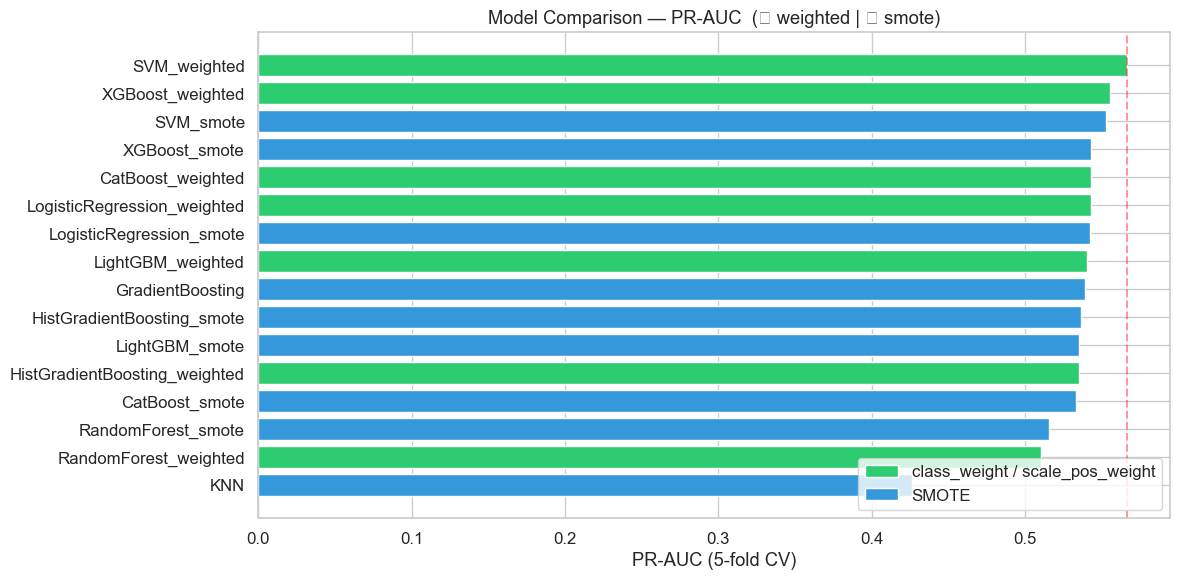


Top-3 моделей: ['SVM_weighted', 'XGBoost_weighted', 'SVM_smote']


In [53]:
from matplotlib.patches import Patch


summary = (
    pd.DataFrame(
        {name: {"PR-AUC (CV)": v["score"], "Mode": v["mode"], 'params': v['params']}
         for name, v in results.items()}
    )
    .T
    .sort_values("PR-AUC (CV)", ascending=False)
    .reset_index()
    .rename(columns={"index": "Model"})
)
summary["PR-AUC (CV)"] = summary["PR-AUC (CV)"].astype(float)
 
print(summary.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(12, 6))
colors = [
    "#2ecc71" if m == "weighted" else "#3498db"
    for m in summary["Mode"]
]
bars = ax.barh(summary["Model"][::-1], summary["PR-AUC (CV)"][::-1], color=colors[::-1])
ax.axvline(summary["PR-AUC (CV)"].iloc[0], color="red", linestyle="--", alpha=0.4)
ax.set_xlabel("PR-AUC (5-fold CV)")
ax.set_title("Model Comparison — PR-AUC  (🟢 weighted | 🔵 smote)")
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.01))
 
legend_elements = [
    Patch(facecolor="#2ecc71", label="class_weight / scale_pos_weight"),
    Patch(facecolor="#3498db", label="SMOTE"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()
 
top3_names = summary["Model"].iloc[:3].tolist()
print(f"\nTop-3 моделей: {top3_names}")

In [54]:
for name, v in results.items():
    print(name, v['params'])

LogisticRegression_weighted {'solver': 'saga', 'C': 18.06362747243349, 'saga_penalty': 'elasticnet', 'l1_ratio': 0.4401315633673214}
LogisticRegression_smote {'solver': 'saga', 'C': 53.525076680789034, 'saga_penalty': 'l2'}
RandomForest_weighted {'n_estimators': 683, 'max_depth': 13, 'min_samples_split': 9, 'min_samples_leaf': 12, 'max_features': 0.3, 'bootstrap': True}
RandomForest_smote {'n_estimators': 449, 'max_depth': 9, 'min_samples_split': 2, 'min_samples_leaf': 12, 'max_features': 0.3, 'bootstrap': True}
GradientBoosting {'n_estimators': 350, 'learning_rate': 0.017087416209247645, 'max_depth': 3, 'min_samples_split': 8, 'min_samples_leaf': 13, 'subsample': 0.907392409961384, 'max_features': 'log2'}
HistGradientBoosting_weighted {'max_iter': 406, 'learning_rate': 0.011821029910933825, 'max_depth': 11, 'min_samples_leaf': 33, 'l2_regularization': 9.041970230159416, 'max_leaf_nodes': 122}
HistGradientBoosting_smote {'max_iter': 545, 'learning_rate': 0.009241851557048503, 'max_dept

In [55]:
def rebuild_pipeline(name, params, mode):
    """
    name  — ключ зі словника results (може містити '_weighted' або '_smote')
    mode  — 'weighted' | 'smote'
    """
    RS = RANDOM_STATE
 
    base = (name
            .replace("_weighted", "")
            .replace("_smote", ""))
 
    use_smote    = (mode == "smote")
    use_weighted = (mode == "weighted")
 
    if base == "LogisticRegression":
        solver  = params["solver"]
        penalty = params.get("saga_penalty") or params.get("liblinear_penalty") or "l2"
        kwargs  = dict(
            C=params["C"], solver=solver, penalty=penalty,
            class_weight="balanced" if use_weighted else None,
            max_iter=2000, random_state=RS,
        )
        if penalty == "elasticnet":
            kwargs["l1_ratio"] = params["l1_ratio"]
        model = LogisticRegression(**kwargs)
 
    elif base == "DecisionTree":
        model = DecisionTreeClassifier(
            criterion=params["criterion"],
            max_depth=params["max_depth"],
            min_samples_split=params["min_samples_split"],
            min_samples_leaf=params["min_samples_leaf"],
            max_features=params["max_features"],
            class_weight="balanced" if use_weighted else None,
            random_state=RS,
        )
 
    elif base == "RandomForest":
        model = RandomForestClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_split=params["min_samples_split"],
            min_samples_leaf=params["min_samples_leaf"],
            max_features=params["max_features"],
            bootstrap=params["bootstrap"],
            class_weight="balanced" if use_weighted else None,
            random_state=RS, n_jobs=-1,
        )
 
    elif base == "ExtraTrees":
        model = ExtraTreesClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_split=params["min_samples_split"],
            min_samples_leaf=params["min_samples_leaf"],
            max_features=params["max_features"],
            class_weight="balanced" if use_weighted else None,
            random_state=RS, n_jobs=-1,
        )
 
    elif base == "GradientBoosting":
        # Тільки smote
        model = GradientBoostingClassifier(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            min_samples_split=params["min_samples_split"],
            min_samples_leaf=params["min_samples_leaf"],
            subsample=params["subsample"],
            max_features=params["max_features"],
            random_state=RS,
        )
 
    elif base == "HistGradientBoosting":
        model = HistGradientBoostingClassifier(
            max_iter=params["max_iter"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            l2_regularization=params["l2_regularization"],
            max_leaf_nodes=params["max_leaf_nodes"],
            class_weight="balanced" if use_weighted else None,
            random_state=RS,
        )
 
    elif base == "SVM":
        kernel = params["kernel"]
        kwargs = dict(
            kernel=kernel,
            C=params["C"],
            gamma=params["gamma"],
            class_weight="balanced" if use_weighted else None,
            probability=True, random_state=RS,
        )
        if "degree" in params:
            kwargs["degree"] = params["degree"]
        if "coef0" in params:
            kwargs["coef0"] = params["coef0"]
        if "coef0_sig" in params:
            kwargs["coef0"] = params["coef0_sig"]
        model = SVC(**kwargs)
 
    elif base == "KNN":
        # Тільки smote
        model = KNeighborsClassifier(
            n_neighbors=params["n_neighbors"],
            weights=params["weights"],
            metric=params["metric"],
            n_jobs=-1,
        )
 
    elif base == "XGBoost":
        model = XGBClassifier(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            min_child_weight=params["min_child_weight"],
            subsample=params["subsample"],
            colsample_bytree=params["colsample_bytree"],
            gamma=params["gamma"],
            reg_alpha=params["reg_alpha"],
            reg_lambda=params["reg_lambda"],
            scale_pos_weight=neg_pos_ratio if use_weighted else 1.0,
            eval_metric="aucpr",
            random_state=RS, n_jobs=-1, verbosity=0,
        )
 
    elif base == "LightGBM":
        model = LGBMClassifier(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            num_leaves=params["num_leaves"],
            max_depth=params["max_depth"],
            min_child_samples=params["min_child_samples"],
            subsample=params["subsample"],
            colsample_bytree=params["colsample_bytree"],
            reg_alpha=params["reg_alpha"],
            reg_lambda=params["reg_lambda"],
            class_weight="balanced" if use_weighted else None,
            random_state=RS, n_jobs=-1, verbose=-1,
        )
 
    elif base == "CatBoost":
        kwargs = dict(
            iterations=params["iterations"],
            learning_rate=params["learning_rate"],
            depth=params["depth"],
            l2_leaf_reg=params["l2_leaf_reg"],
            bagging_temperature=params["bagging_temperature"],
            border_count=params["border_count"],
            random_seed=RS, verbose=False,
        )
        if use_weighted:
            kwargs["auto_class_weights"] = "Balanced"
        model = CatBoostClassifier(**kwargs)
 
    else:
        raise ValueError(f"Unknown model: {base}")
 
    return smote_pipe(model) if use_smote else weighted_pipe(model)
 
 
best_pipelines = {}
for name, r in results.items():
    best_pipelines[name] = rebuild_pipeline(name, r["params"], r["mode"])
 
print("Pipelines rebuilt for:", list(best_pipelines.keys()))

Pipelines rebuilt for: ['LogisticRegression_weighted', 'LogisticRegression_smote', 'RandomForest_weighted', 'RandomForest_smote', 'GradientBoosting', 'HistGradientBoosting_weighted', 'HistGradientBoosting_smote', 'SVM_weighted', 'SVM_smote', 'KNN', 'XGBoost_weighted', 'XGBoost_smote', 'LightGBM_weighted', 'LightGBM_smote', 'CatBoost_weighted', 'CatBoost_smote']


In [60]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("binary_classification")

overfit_rows = []

for name in summary["Model"]:
    pipe = best_pipelines[name]

    cv_metrics = cv_pr_auc(pipe, X_train, y_train, return_all_metrics=True)

    pipe.fit(X_train, y_train)

    y_proba_tr = pipe.predict_proba(X_train)[:, 1]
    y_proba_te = pipe.predict_proba(X_test)[:, 1]
    y_pred_te  = pipe.predict(X_test)

    train_pr_auc = average_precision_score(y_train, y_proba_tr)
    test_pr_auc  = average_precision_score(y_test,  y_proba_te)
    cv_mean      = cv_metrics["pr_auc"]["mean"]

    row = {
        "Model":              name,
        "Mode":               results[name]["mode"],
        "Train PR-AUC":       round(train_pr_auc, 4),
        "CV PR-AUC":          round(cv_mean, 4),
        "CV PR-AUC Std":      round(cv_metrics["pr_auc"]["std"], 4),
        "Test PR-AUC":        round(test_pr_auc, 4),
        "Train - CV":         round(train_pr_auc - cv_mean, 4),
        "CV ROC-AUC":         round(cv_metrics["roc_auc"]["mean"], 4),
        "CV ROC-AUC Std":     round(cv_metrics["roc_auc"]["std"], 4),
        "CV F1":              round(cv_metrics["f1"]["mean"], 4),
        "CV F1 Std":          round(cv_metrics["f1"]["std"], 4),
        "CV Recall":          round(cv_metrics["recall"]["mean"], 4),
        "CV Recall Std":      round(cv_metrics["recall"]["std"], 4),
        "CV Precision":       round(cv_metrics["precision"]["mean"], 4),
        "CV Precision Std":   round(cv_metrics["precision"]["std"], 4),
        "Test ROC-AUC":       round(roc_auc_score(y_test, y_proba_te), 4),
        "Test F1":            round(f1_score(y_test, y_pred_te, zero_division=0), 4),
        "Test Recall":        round(recall_score(y_test, y_pred_te, zero_division=0), 4),
        "Test Precision":     round(precision_score(y_test, y_pred_te, zero_division=0), 4),
    }

    with mlflow.start_run(run_name=name):
        mlflow.log_param("model", name)
        mlflow.log_param("mode", results[name]["mode"])

        mlflow.log_metrics({k: v for k, v in row.items() if isinstance(v, float)})

        mlflow.sklearn.log_model(
            pipe, 
            artifact_path="model",
            input_example=X_train[:5] 
        )

    overfit_rows.append(row)

overfit_df = (
    pd.DataFrame(overfit_rows)
    .sort_values("CV PR-AUC", ascending=False)
    .reset_index(drop=True)
)

print("=== Final Training Results — Overfit Check ===")
overfit_df

2026/04/07 18:41:30 INFO mlflow.tracking.fluent: Experiment with name 'binary_classification' does not exist. Creating a new experiment.


=== Final Training Results — Overfit Check ===


,Model,Mode,Train PR-AUC,CV PR-AUC,CV PR-AUC Std,Test PR-AUC,Train - CV,CV ROC-AUC,CV ROC-AUC Std,CV F1,CV F1 Std,CV Recall,CV Recall Std,CV Precision,CV Precision Std,Test ROC-AUC,Test F1,Test Recall,Test Precision
0,SVM_weighted,weighted,0.6737,0.5665,0.0516,0.5571,0.1072,0.8740,0.0179,0.5318,0.0277,0.8096,0.0528,0.3971,0.0283,0.8713,0.5348,0.8065,0.4000
1,XGBoost_weighted,weighted,0.8392,0.5553,0.0752,0.5210,0.2838,0.8724,0.0205,0.5515,0.0249,0.7247,0.0237,0.4472,0.0397,0.8647,0.4966,0.5968,0.4253
2,SVM_smote,smote,0.5936,0.5531,0.0811,0.5279,0.0405,0.8665,0.0278,0.5515,0.0492,0.7976,0.0442,0.4230,0.0514,0.8625,0.5363,0.7742,0.4103
3,XGBoost_smote,smote,0.8704,0.5432,0.0410,0.4860,0.3272,0.8718,0.0158,0.5601,0.0505,0.5749,0.0227,0.5518,0.0913,0.8383,0.4874,0.4677,0.5088
4,CatBoost_weighted,weighted,0.8312,0.5431,0.0705,0.5215,0.2881,0.8713,0.0204,0.5429,0.0363,0.7128,0.0488,0.4404,0.0422,0.8580,0.5467,0.6613,0.4659
5,LogisticRegression_weighted,weighted,0.5446,0.5428,0.0808,0.5153,0.0017,0.8630,0.0260,0.5191,0.0325,0.7855,0.0455,0.3885,0.0319,0.8577,0.5348,0.8065,0.4000
6,LogisticRegression_smote,smote,0.5452,0.5423,0.0870,0.5195,0.0029,0.8624,0.0275,0.5366,0.0406,0.7692,0.0399,0.4137,0.0455,0.8554,0.5517,0.7742,0.4286
7,LightGBM_weighted,weighted,0.8028,0.5406,0.0773,0.4707,0.2622,0.8674,0.0193,0.5312,0.0317,0.7371,0.0485,0.4185,0.0462,0.8362,0.4634,0.6129,0.3725
8,GradientBoosting,smote,0.7648,0.5392,0.0326,0.5205,0.2256,0.8650,0.0143,0.5485,0.0306,0.6153,0.0301,0.4994,0.0596,0.8476,0.5231,0.5484,0.5000
9,HistGradientBoosting_smote,smote,0.7239,0.5365,0.0548,0.4429,0.1874,0.8692,0.0137,0.5496,0.0437,0.6076,0.0383,0.5057,0.0681,0.8353,0.4844,0.5000,0.4697


In [61]:
overfit_df = overfit_df[overfit_df["Train - CV"] <= 10].sort_values("Train - CV")

In [62]:
overfit_df

,Model,Mode,Train PR-AUC,CV PR-AUC,CV PR-AUC Std,Test PR-AUC,Train - CV,CV ROC-AUC,CV ROC-AUC Std,CV F1,CV F1 Std,CV Recall,CV Recall Std,CV Precision,CV Precision Std,Test ROC-AUC,Test F1,Test Recall,Test Precision
5,LogisticRegression_weighted,weighted,0.5446,0.5428,0.0808,0.5153,0.0017,0.8630,0.0260,0.5191,0.0325,0.7855,0.0455,0.3885,0.0319,0.8577,0.5348,0.8065,0.4000
6,LogisticRegression_smote,smote,0.5452,0.5423,0.0870,0.5195,0.0029,0.8624,0.0275,0.5366,0.0406,0.7692,0.0399,0.4137,0.0455,0.8554,0.5517,0.7742,0.4286
2,SVM_smote,smote,0.5936,0.5531,0.0811,0.5279,0.0405,0.8665,0.0278,0.5515,0.0492,0.7976,0.0442,0.4230,0.0514,0.8625,0.5363,0.7742,0.4103
0,SVM_weighted,weighted,0.6737,0.5665,0.0516,0.5571,0.1072,0.8740,0.0179,0.5318,0.0277,0.8096,0.0528,0.3971,0.0283,0.8713,0.5348,0.8065,0.4000
15,KNN,smote,0.5569,0.4006,0.0458,0.3773,0.1563,0.8072,0.0229,0.4530,0.0228,0.7731,0.0510,0.3210,0.0197,0.7772,0.4224,0.7903,0.2882
9,HistGradientBoosting_smote,smote,0.7239,0.5365,0.0548,0.4429,0.1874,0.8692,0.0137,0.5496,0.0437,0.6076,0.0383,0.5057,0.0681,0.8353,0.4844,0.5000,0.4697
12,CatBoost_smote,smote,0.7323,0.5335,0.0393,0.5258,0.1988,0.8675,0.0177,0.5583,0.0333,0.6193,0.0168,0.5111,0.0570,0.8536,0.5197,0.5323,0.5077
8,GradientBoosting,smote,0.7648,0.5392,0.0326,0.5205,0.2256,0.8650,0.0143,0.5485,0.0306,0.6153,0.0301,0.4994,0.0596,0.8476,0.5231,0.5484,0.5000
7,LightGBM_weighted,weighted,0.8028,0.5406,0.0773,0.4707,0.2622,0.8674,0.0193,0.5312,0.0317,0.7371,0.0485,0.4185,0.0462,0.8362,0.4634,0.6129,0.3725
1,XGBoost_weighted,weighted,0.8392,0.5553,0.0752,0.5210,0.2838,0.8724,0.0205,0.5515,0.0249,0.7247,0.0237,0.4472,0.0397,0.8647,0.4966,0.5968,0.4253


Feature importance for: LogisticRegression_weighted


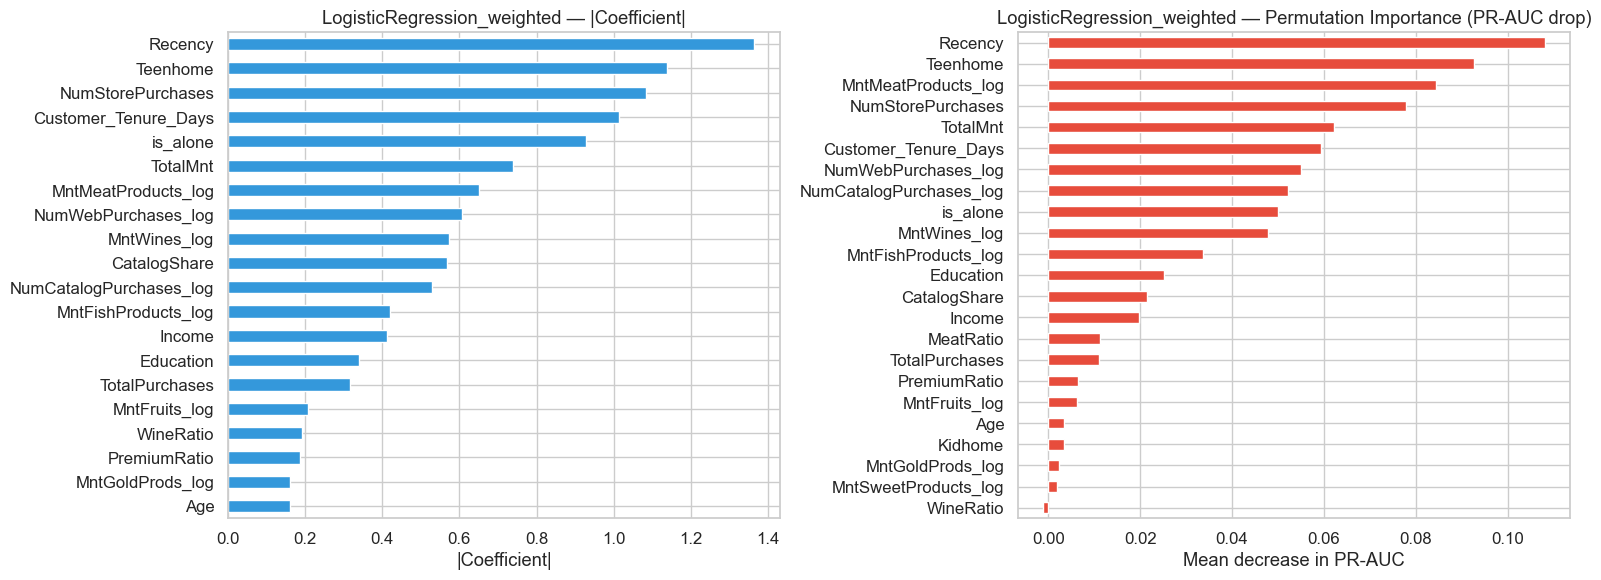

In [63]:
best_model_name = overfit_df["Model"].iloc[0]
print(f"Feature importance for: {best_model_name}")
 
best_pipe = best_pipelines[best_model_name]
 
prep_fitted   = best_pipe.named_steps["prep"]
feature_names = [
    f.replace("std__", "").replace("robust__", "").replace("pass__", "")
    for f in prep_fitted.get_feature_names_out()
]
 
model_step = best_pipe.named_steps["model"]
 
has_native_importance = hasattr(model_step, "feature_importances_")
has_coef              = hasattr(model_step, "coef_")
 
fig, axes = plt.subplots(
    1, 2 if (has_native_importance or has_coef) else 1,
    figsize=(16, 6),
)
axes = [axes] if not isinstance(axes, np.ndarray) else axes
 
if has_native_importance:
    imp = model_step.feature_importances_
    imp_series = pd.Series(imp, index=feature_names).sort_values(ascending=True).tail(20)
    imp_series.plot(kind="barh", ax=axes[0], color="#3498db")
    axes[0].set_title(f"{best_model_name} — Native Feature Importance")
    axes[0].set_xlabel("Importance")
elif has_coef:
    imp = np.abs(model_step.coef_[0]) if model_step.coef_.ndim > 1 else np.abs(model_step.coef_)
    imp_series = pd.Series(imp, index=feature_names).sort_values(ascending=True).tail(20)
    imp_series.plot(kind="barh", ax=axes[0], color="#3498db")
    axes[0].set_title(f"{best_model_name} — |Coefficient|")
    axes[0].set_xlabel("|Coefficient|")
 
X_train_prep = prep_fitted.transform(X_train)
perm_result  = permutation_importance(
    model_step, X_train_prep, y_train,
    n_repeats=15,
    scoring="average_precision",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
perm_series = (
    pd.Series(perm_result.importances_mean, index=feature_names)
    .sort_values(ascending=True)
)
perm_series.plot(kind="barh", ax=axes[-1], color="#e74c3c")
axes[-1].set_title(f"{best_model_name} — Permutation Importance (PR-AUC drop)")
axes[-1].set_xlabel("Mean decrease in PR-AUC")
 
plt.tight_layout()
plt.show()

Feature importance for: LogisticRegression_smote


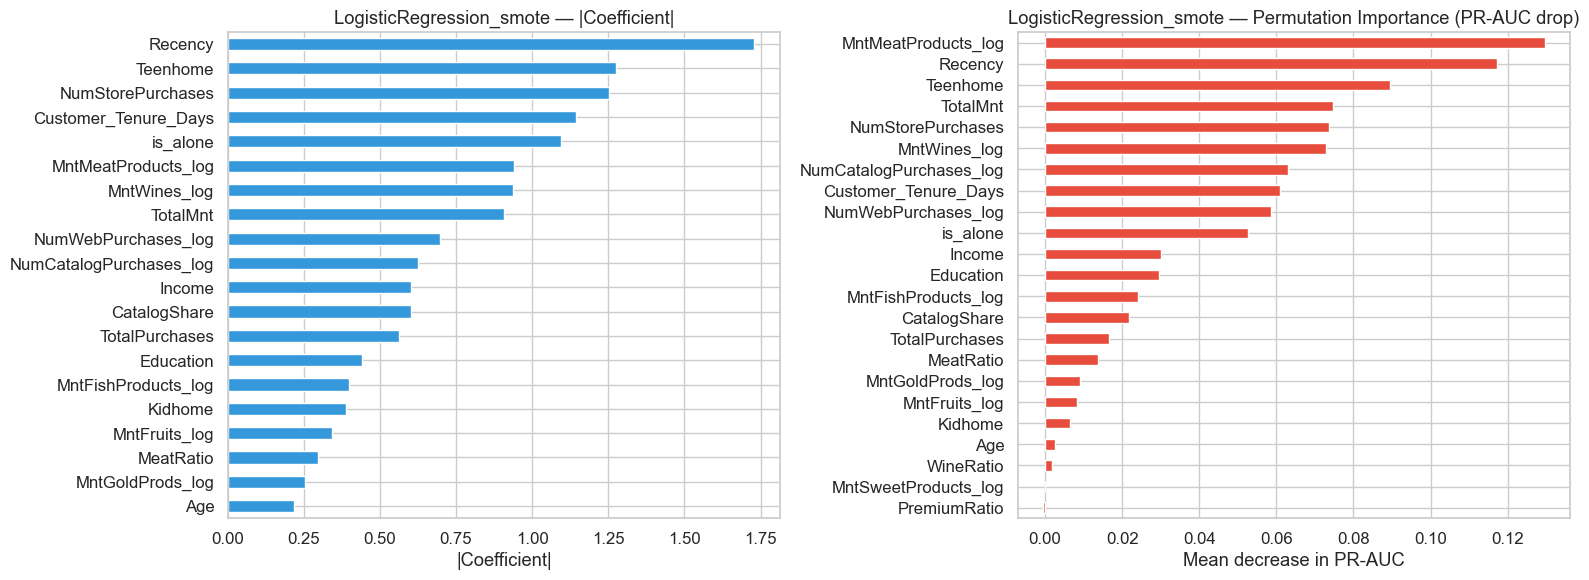

In [64]:
best_model_name = 'LogisticRegression_smote'
print(f"Feature importance for: {best_model_name}")
 
best_pipe = best_pipelines[best_model_name]
 
prep_fitted   = best_pipe.named_steps["prep"]
feature_names = [
    f.replace("std__", "").replace("robust__", "").replace("pass__", "")
    for f in prep_fitted.get_feature_names_out()
]
 
model_step = best_pipe.named_steps["model"]
 
has_native_importance = hasattr(model_step, "feature_importances_")
has_coef              = hasattr(model_step, "coef_")
 
fig, axes = plt.subplots(
    1, 2 if (has_native_importance or has_coef) else 1,
    figsize=(16, 6),
)
axes = [axes] if not isinstance(axes, np.ndarray) else axes
 
if has_native_importance:
    imp = model_step.feature_importances_
    imp_series = pd.Series(imp, index=feature_names).sort_values(ascending=True).tail(20)
    imp_series.plot(kind="barh", ax=axes[0], color="#3498db")
    axes[0].set_title(f"{best_model_name} — Native Feature Importance")
    axes[0].set_xlabel("Importance")
elif has_coef:
    imp = np.abs(model_step.coef_[0]) if model_step.coef_.ndim > 1 else np.abs(model_step.coef_)
    imp_series = pd.Series(imp, index=feature_names).sort_values(ascending=True).tail(20)
    imp_series.plot(kind="barh", ax=axes[0], color="#3498db")
    axes[0].set_title(f"{best_model_name} — |Coefficient|")
    axes[0].set_xlabel("|Coefficient|")
 
X_train_prep = prep_fitted.transform(X_train)
perm_result  = permutation_importance(
    model_step, X_train_prep, y_train,
    n_repeats=15,
    scoring="average_precision",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
perm_series = (
    pd.Series(perm_result.importances_mean, index=feature_names)
    .sort_values(ascending=True)
)
perm_series.plot(kind="barh", ax=axes[-1], color="#e74c3c")
axes[-1].set_title(f"{best_model_name} — Permutation Importance (PR-AUC drop)")
axes[-1].set_xlabel("Mean decrease in PR-AUC")
 
plt.tight_layout()
plt.show()

Feature importance for: SVM_smote


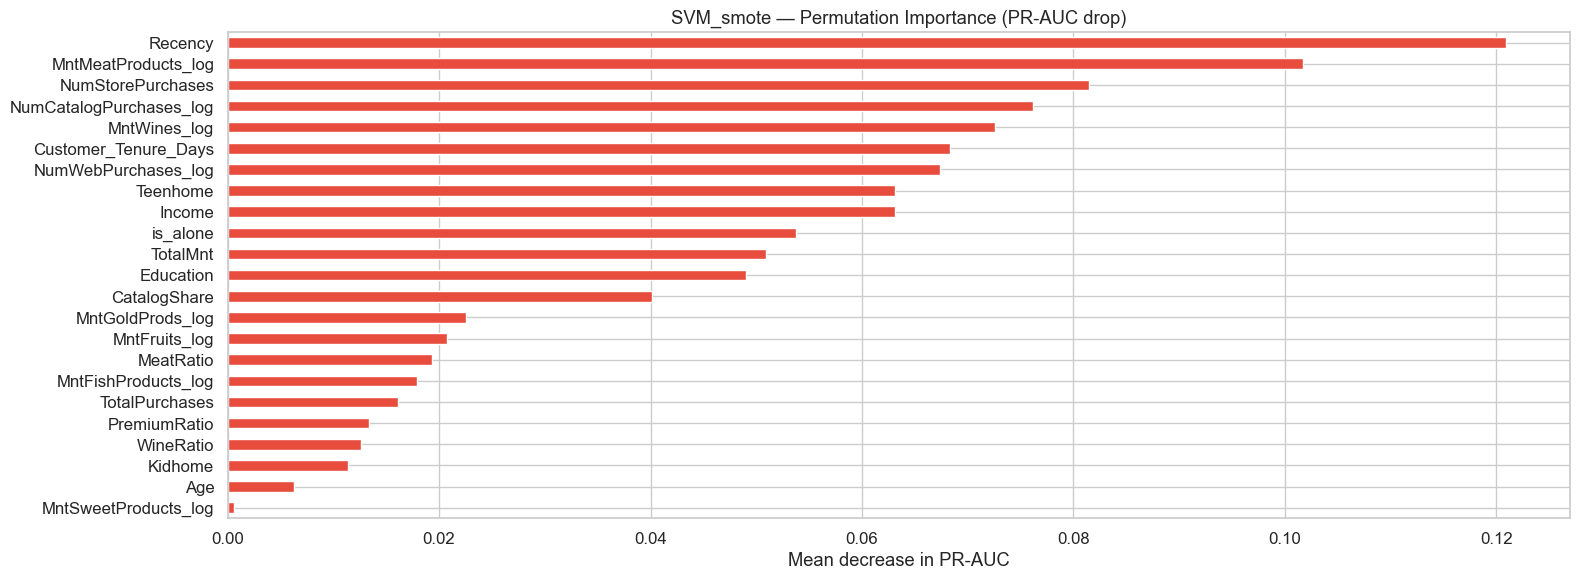

In [65]:
best_model_name = 'SVM_smote'
print(f"Feature importance for: {best_model_name}")
 
best_pipe = best_pipelines[best_model_name]
 
prep_fitted   = best_pipe.named_steps["prep"]
feature_names = [
    f.replace("std__", "").replace("robust__", "").replace("pass__", "")
    for f in prep_fitted.get_feature_names_out()
]
 
model_step = best_pipe.named_steps["model"]
 
has_native_importance = hasattr(model_step, "feature_importances_")
has_coef              = hasattr(model_step, "coef_")
 
fig, axes = plt.subplots(
    1, 2 if (has_native_importance or has_coef) else 1,
    figsize=(16, 6),
)
axes = [axes] if not isinstance(axes, np.ndarray) else axes
 
if has_native_importance:
    imp = model_step.feature_importances_
    imp_series = pd.Series(imp, index=feature_names).sort_values(ascending=True).tail(20)
    imp_series.plot(kind="barh", ax=axes[0], color="#3498db")
    axes[0].set_title(f"{best_model_name} — Native Feature Importance")
    axes[0].set_xlabel("Importance")
elif has_coef:
    imp = np.abs(model_step.coef_[0]) if model_step.coef_.ndim > 1 else np.abs(model_step.coef_)
    imp_series = pd.Series(imp, index=feature_names).sort_values(ascending=True).tail(20)
    imp_series.plot(kind="barh", ax=axes[0], color="#3498db")
    axes[0].set_title(f"{best_model_name} — |Coefficient|")
    axes[0].set_xlabel("|Coefficient|")
 
X_train_prep = prep_fitted.transform(X_train)
perm_result  = permutation_importance(
    model_step, X_train_prep, y_train,
    n_repeats=15,
    scoring="average_precision",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
perm_series = (
    pd.Series(perm_result.importances_mean, index=feature_names)
    .sort_values(ascending=True)
)
perm_series.plot(kind="barh", ax=axes[-1], color="#e74c3c")
axes[-1].set_title(f"{best_model_name} — Permutation Importance (PR-AUC drop)")
axes[-1].set_xlabel("Mean decrease in PR-AUC")
 
plt.tight_layout()
plt.show()

Топ-4 моделі: ['LogisticRegression_weighted', 'LogisticRegression_smote', 'SVM_smote', 'SVM_weighted']

  МОДЕЛЬ: LogisticRegression_weighted

 CV по фолдам (F3.0-оптимальний threshold):
    threshold  recall  precision     f1   f3.0     f2  roc_auc  pr_auc    mcc  balanced_acc  specificity      tp       fp       tn     fn fold
       0.3800  0.9592     0.3481 0.5109 0.8160 0.7100   0.8933  0.5993 0.4645        0.8196       0.6800 47.0000  88.0000 187.0000 2.0000     
       0.2100  0.9800     0.2390 0.3843 0.7481 0.6049   0.8341  0.4576 0.3077        0.7053       0.4307 49.0000 156.0000 118.0000 1.0000     
       0.4050  0.9200     0.3511 0.5083 0.7917 0.6949   0.8528  0.5324 0.4489        0.8049       0.6898 46.0000  85.0000 189.0000 4.0000     
       0.2600  0.9796     0.2963 0.4550 0.7960 0.6704   0.8946  0.6656 0.4043        0.7818       0.5839 48.0000 114.0000 160.0000 1.0000     
       0.1850  0.9796     0.2437 0.3902 0.7524 0.6107   0.8404  0.4592 0.3205        0.7179       

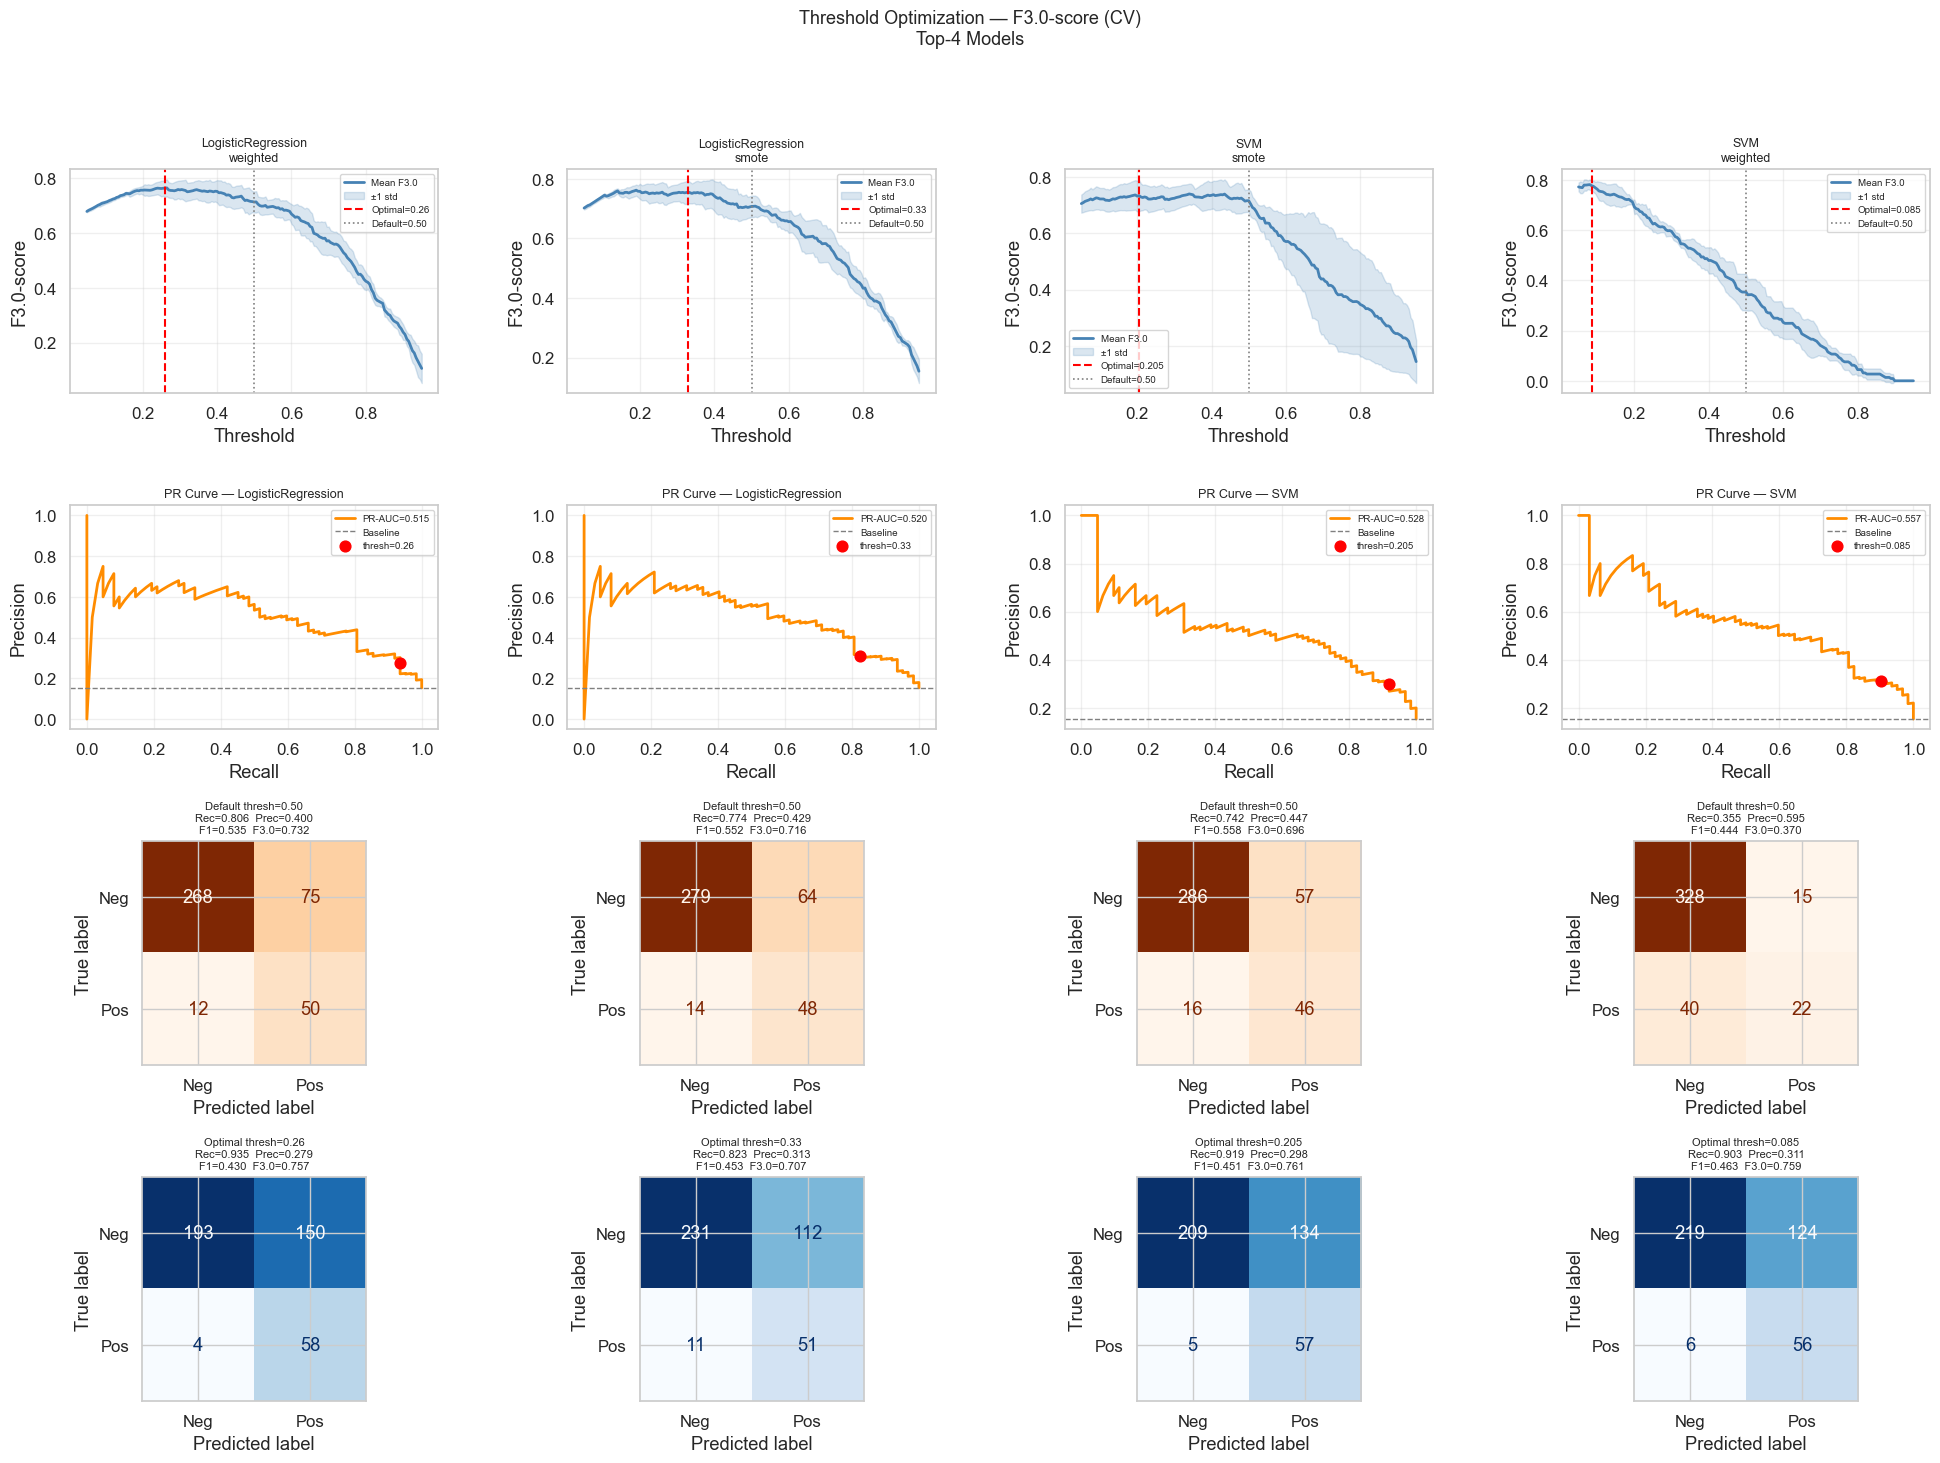

In [66]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    precision_recall_curve, fbeta_score, recall_score, precision_score,
    f1_score, roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, matthews_corrcoef, balanced_accuracy_score,
    ConfusionMatrixDisplay
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


top3_names = overfit_df.head(4)["Model"].tolist()
print("Топ-4 моделі:", top3_names)


def compute_all_metrics(y_true, y_pred, y_proba, beta=2.0):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return {
        "recall":       round(recall_score(y_true, y_pred, zero_division=0), 4),
        "precision":    round(precision_score(y_true, y_pred, zero_division=0), 4),
        "f1":           round(f1_score(y_true, y_pred, zero_division=0), 4),
        f"f{beta}":     round(fbeta_score(y_true, y_pred, beta=beta, zero_division=0), 4),
        "f2":           round(fbeta_score(y_true, y_pred, beta=2.0, zero_division=0), 4),
        "roc_auc":      round(roc_auc_score(y_true, y_proba), 4),
        "pr_auc":       round(average_precision_score(y_true, y_proba), 4),
        "mcc":          round(matthews_corrcoef(y_true, y_pred), 4),
        "balanced_acc": round(balanced_accuracy_score(y_true, y_pred), 4),
        "specificity":  round(specificity, 4),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
    }


def find_optimal_threshold_cv(pipeline, X, y, beta=2.0, n_splits=5, thresholds_grid=None):
    if thresholds_grid is None:
        thresholds_grid = np.linspace(0.05, 0.95, 181)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []
    optimal_thresholds = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        from sklearn.base import clone
        pipe_fold = clone(pipeline)
        pipe_fold.fit(X_tr, y_tr)

        y_proba_val = pipe_fold.predict_proba(X_val)[:, 1]

        best_fbeta, best_thresh = -1, 0.5
        fbeta_scores = []

        for thresh in thresholds_grid:
            y_pred_thresh = (y_proba_val >= thresh).astype(int)
            fb = fbeta_score(y_val, y_pred_thresh, beta=beta, zero_division=0)
            fbeta_scores.append(fb)
            if fb > best_fbeta:
                best_fbeta = fb
                best_thresh = thresh

        optimal_thresholds.append(best_thresh)
        y_pred_opt = (y_proba_val >= best_thresh).astype(int)
        metrics = compute_all_metrics(y_val, y_pred_opt, y_proba_val, beta=beta)

        fold_results.append({
            "fold":        fold + 1,
            "threshold":   round(best_thresh, 4),
            **metrics,
            "fbeta_curve": fbeta_scores,
        })

    optimal_thresholds = np.array(optimal_thresholds)
    threshold_stats = {
        "mean":   round(float(np.mean(optimal_thresholds)), 4),
        "median": round(float(np.median(optimal_thresholds)), 4),
        "std":    round(float(np.std(optimal_thresholds)), 4),
        "min":    round(float(np.min(optimal_thresholds)), 4),
        "max":    round(float(np.max(optimal_thresholds)), 4),
    }

    return threshold_stats["median"], fold_results, threshold_stats


BETA = 3.0
threshold_results = {}

CV_METRIC_COLS = ["threshold", "recall", "precision", "f1", f"f{BETA}",
                  "f2", "roc_auc", "pr_auc", "mcc", "balanced_acc",
                  "specificity", "tp", "fp", "tn", "fn"]

for name in top3_names:
    print(f"\n{'='*70}")
    print(f"  МОДЕЛЬ: {name}")
    print(f"{'='*70}")

    pipe = best_pipelines[name]

    best_thresh, fold_results, stats = find_optimal_threshold_cv(
        pipeline=pipe, X=X_train, y=y_train, beta=BETA, n_splits=5,
    )

    cv_df = pd.DataFrame(fold_results)[CV_METRIC_COLS]

    numeric_cols = [c for c in CV_METRIC_COLS if c != "threshold"]
    mean_row = {c: round(cv_df[c].mean(), 4) for c in numeric_cols}
    std_row  = {c: round(cv_df[c].std(), 4)  for c in numeric_cols}
    mean_row["threshold"] = f"{stats['mean']} ± {stats['std']}"
    std_row["threshold"]  = "(std)"

    cv_display = pd.concat([
        cv_df,
        pd.DataFrame([{**mean_row, **{"fold": "mean"}}]),
    ], ignore_index=True).fillna("")

    print(f"\n CV по фолдам (F{BETA}-оптимальний threshold):")
    print(cv_display.to_string(index=False))
    print(f"\n Статистика threshold: {stats}")
    print(f"→  Обраний threshold (медіана): {best_thresh}")

    pipe.fit(X_train, y_train)
    y_proba_test = pipe.predict_proba(X_test)[:, 1]

    y_pred_default = (y_proba_test >= 0.50).astype(int)
    y_pred_optimal = (y_proba_test >= best_thresh).astype(int)

    m_default = compute_all_metrics(y_test, y_pred_default, y_proba_test, beta=BETA)
    m_optimal = compute_all_metrics(y_test, y_pred_optimal, y_proba_test, beta=BETA)

    threshold_results[name] = {
        "best_threshold":  best_thresh,
        "fold_results":    fold_results,
        "stats":           stats,
        "test_default":    m_default,
        "test_optimal":    m_optimal,
        "y_proba_test":    y_proba_test,
        "y_pred_default":  y_pred_default,
        "y_pred_optimal":  y_pred_optimal,
    }

    print(f"\n TEST SET — порівняння метрик:")
    cmp_df = pd.DataFrame({
        "Metric":        list(m_default.keys()),
        "Default (0.50)": list(m_default.values()),
        f"Optimal ({best_thresh})": list(m_optimal.values()),
        "Delta":         [round(m_optimal[k] - m_default[k], 4)
                          if isinstance(m_optimal[k], float) else "—"
                          for k in m_default],
    })
    print(cmp_df.to_string(index=False))

    print(f"\n Classification Report (optimal threshold={best_thresh}):")
    print(classification_report(y_test, y_pred_optimal, zero_division=0))

print(f"\n{'='*70}")
print("ЗВЕДЕНА ТАБЛИЦЯ TEST — дефолт 0.5 vs оптимальний threshold")
print(f"{'='*70}")

summary_rows = []
for name in top3_names:
    res = threshold_results[name]
    for label, metrics in [("default_0.50", res["test_default"]),
                            (f"optimal_{res['best_threshold']}", res["test_optimal"])]:
        summary_rows.append({"Model": name, "Threshold": label, **{
            k: v for k, v in metrics.items()
            if k not in ("tp", "fp", "tn", "fn")
        }})

summary_thresh_df = pd.DataFrame(summary_rows)
print(summary_thresh_df.to_string(index=False))

thresholds_grid = np.linspace(0.05, 0.95, 181)
n = len(top3_names)

fig = plt.figure(figsize=(6 * n, 16))
gs = gridspec.GridSpec(4, n, figure=fig, hspace=0.5, wspace=0.35)

for col, name in enumerate(top3_names):
    res = threshold_results[name]
    opt_thresh = res["best_threshold"]

    ax_curve = fig.add_subplot(gs[0, col])
    all_curves = np.array([f["fbeta_curve"] for f in res["fold_results"]])
    mean_c = all_curves.mean(axis=0)
    std_c  = all_curves.std(axis=0)

    ax_curve.plot(thresholds_grid, mean_c, color="steelblue", lw=2, label=f"Mean F{BETA}")
    ax_curve.fill_between(thresholds_grid, mean_c - std_c, mean_c + std_c,
                          alpha=0.2, color="steelblue", label="±1 std")
    ax_curve.axvline(opt_thresh, color="red",  linestyle="--", lw=1.5, label=f"Optimal={opt_thresh}")
    ax_curve.axvline(0.50,       color="gray", linestyle=":",  lw=1.2, label="Default=0.50")
    ax_curve.set_title(name.replace("_", "\n"), fontsize=9)
    ax_curve.set_xlabel("Threshold")
    ax_curve.set_ylabel(f"F{BETA}-score")
    ax_curve.legend(fontsize=7)
    ax_curve.grid(True, alpha=0.3)

    ax_pr = fig.add_subplot(gs[1, col])
    prec, rec, thr = precision_recall_curve(y_test, res["y_proba_test"])
    pr_auc_val = average_precision_score(y_test, res["y_proba_test"])

    ax_pr.plot(rec, prec, color="darkorange", lw=2, label=f"PR-AUC={pr_auc_val:.3f}")
    ax_pr.axhline(y_test.mean(), color="gray", linestyle="--", lw=1, label="Baseline")

    idx_opt = np.argmin(np.abs(thr - opt_thresh)) if len(thr) > 0 else None
    if idx_opt is not None:
        ax_pr.scatter(rec[idx_opt], prec[idx_opt], color="red", zorder=5,
                      label=f"thresh={opt_thresh}", s=60)

    ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision")
    ax_pr.set_title(f"PR Curve — {name.split('_')[0]}", fontsize=9)
    ax_pr.legend(fontsize=7)
    ax_pr.grid(True, alpha=0.3)

    ax_cm_def = fig.add_subplot(gs[2, col])
    cm_def = confusion_matrix(y_test, res["y_pred_default"])
    disp_def = ConfusionMatrixDisplay(cm_def, display_labels=["Neg", "Pos"])
    disp_def.plot(ax=ax_cm_def, colorbar=False, cmap="Oranges")
    m_def = res["test_default"]
    ax_cm_def.set_title(
        f"Default thresh=0.50\n"
        f"Rec={m_def['recall']:.3f}  Prec={m_def['precision']:.3f}\n"
        f"F1={m_def['f1']:.3f}  F{BETA}={m_def[f'f{BETA}']:.3f}",
        fontsize=8
    )

    ax_cm_opt = fig.add_subplot(gs[3, col])
    cm_opt = confusion_matrix(y_test, res["y_pred_optimal"])
    disp_opt = ConfusionMatrixDisplay(cm_opt, display_labels=["Neg", "Pos"])
    disp_opt.plot(ax=ax_cm_opt, colorbar=False, cmap="Blues")
    m_opt = res["test_optimal"]
    ax_cm_opt.set_title(
        f"Optimal thresh={opt_thresh}\n"
        f"Rec={m_opt['recall']:.3f}  Prec={m_opt['precision']:.3f}\n"
        f"F1={m_opt['f1']:.3f}  F{BETA}={m_opt[f'f{BETA}']:.3f}",
        fontsize=8
    )

fig.suptitle(f"Threshold Optimization — F{BETA}-score (CV)\nTop-{n} Models", fontsize=13)
plt.show()

Топ-4 моделі: ['LogisticRegression_weighted', 'LogisticRegression_smote', 'SVM_smote', 'SVM_weighted']

  МОДЕЛЬ: LogisticRegression_weighted

 CV по фолдам (F2.0-оптимальний threshold):
     threshold  recall  precision     f1   f2.0     f2  roc_auc  pr_auc    mcc  balanced_acc  specificity      tp       fp       tn      fn fold
        0.4650  0.9184     0.3879 0.5455 0.7212 0.7212   0.8933  0.5993 0.4934        0.8301       0.7418 45.0000  71.0000 204.0000  4.0000     
        0.6150  0.7600     0.4368 0.5547 0.6620 0.6620   0.8341  0.4576 0.4737        0.7906       0.8212 38.0000  49.0000 225.0000 12.0000     
        0.4050  0.9200     0.3511 0.5083 0.6949 0.6949   0.8528  0.5324 0.4489        0.8049       0.6898 46.0000  85.0000 189.0000  4.0000     
        0.5950  0.7347     0.5538 0.6316 0.6897 0.6897   0.8946  0.6656 0.5627        0.8144       0.8942 36.0000  29.0000 245.0000 13.0000     
        0.2950  0.8980     0.2953 0.4444 0.6377 0.6377   0.8404  0.4592 0.3704        0.

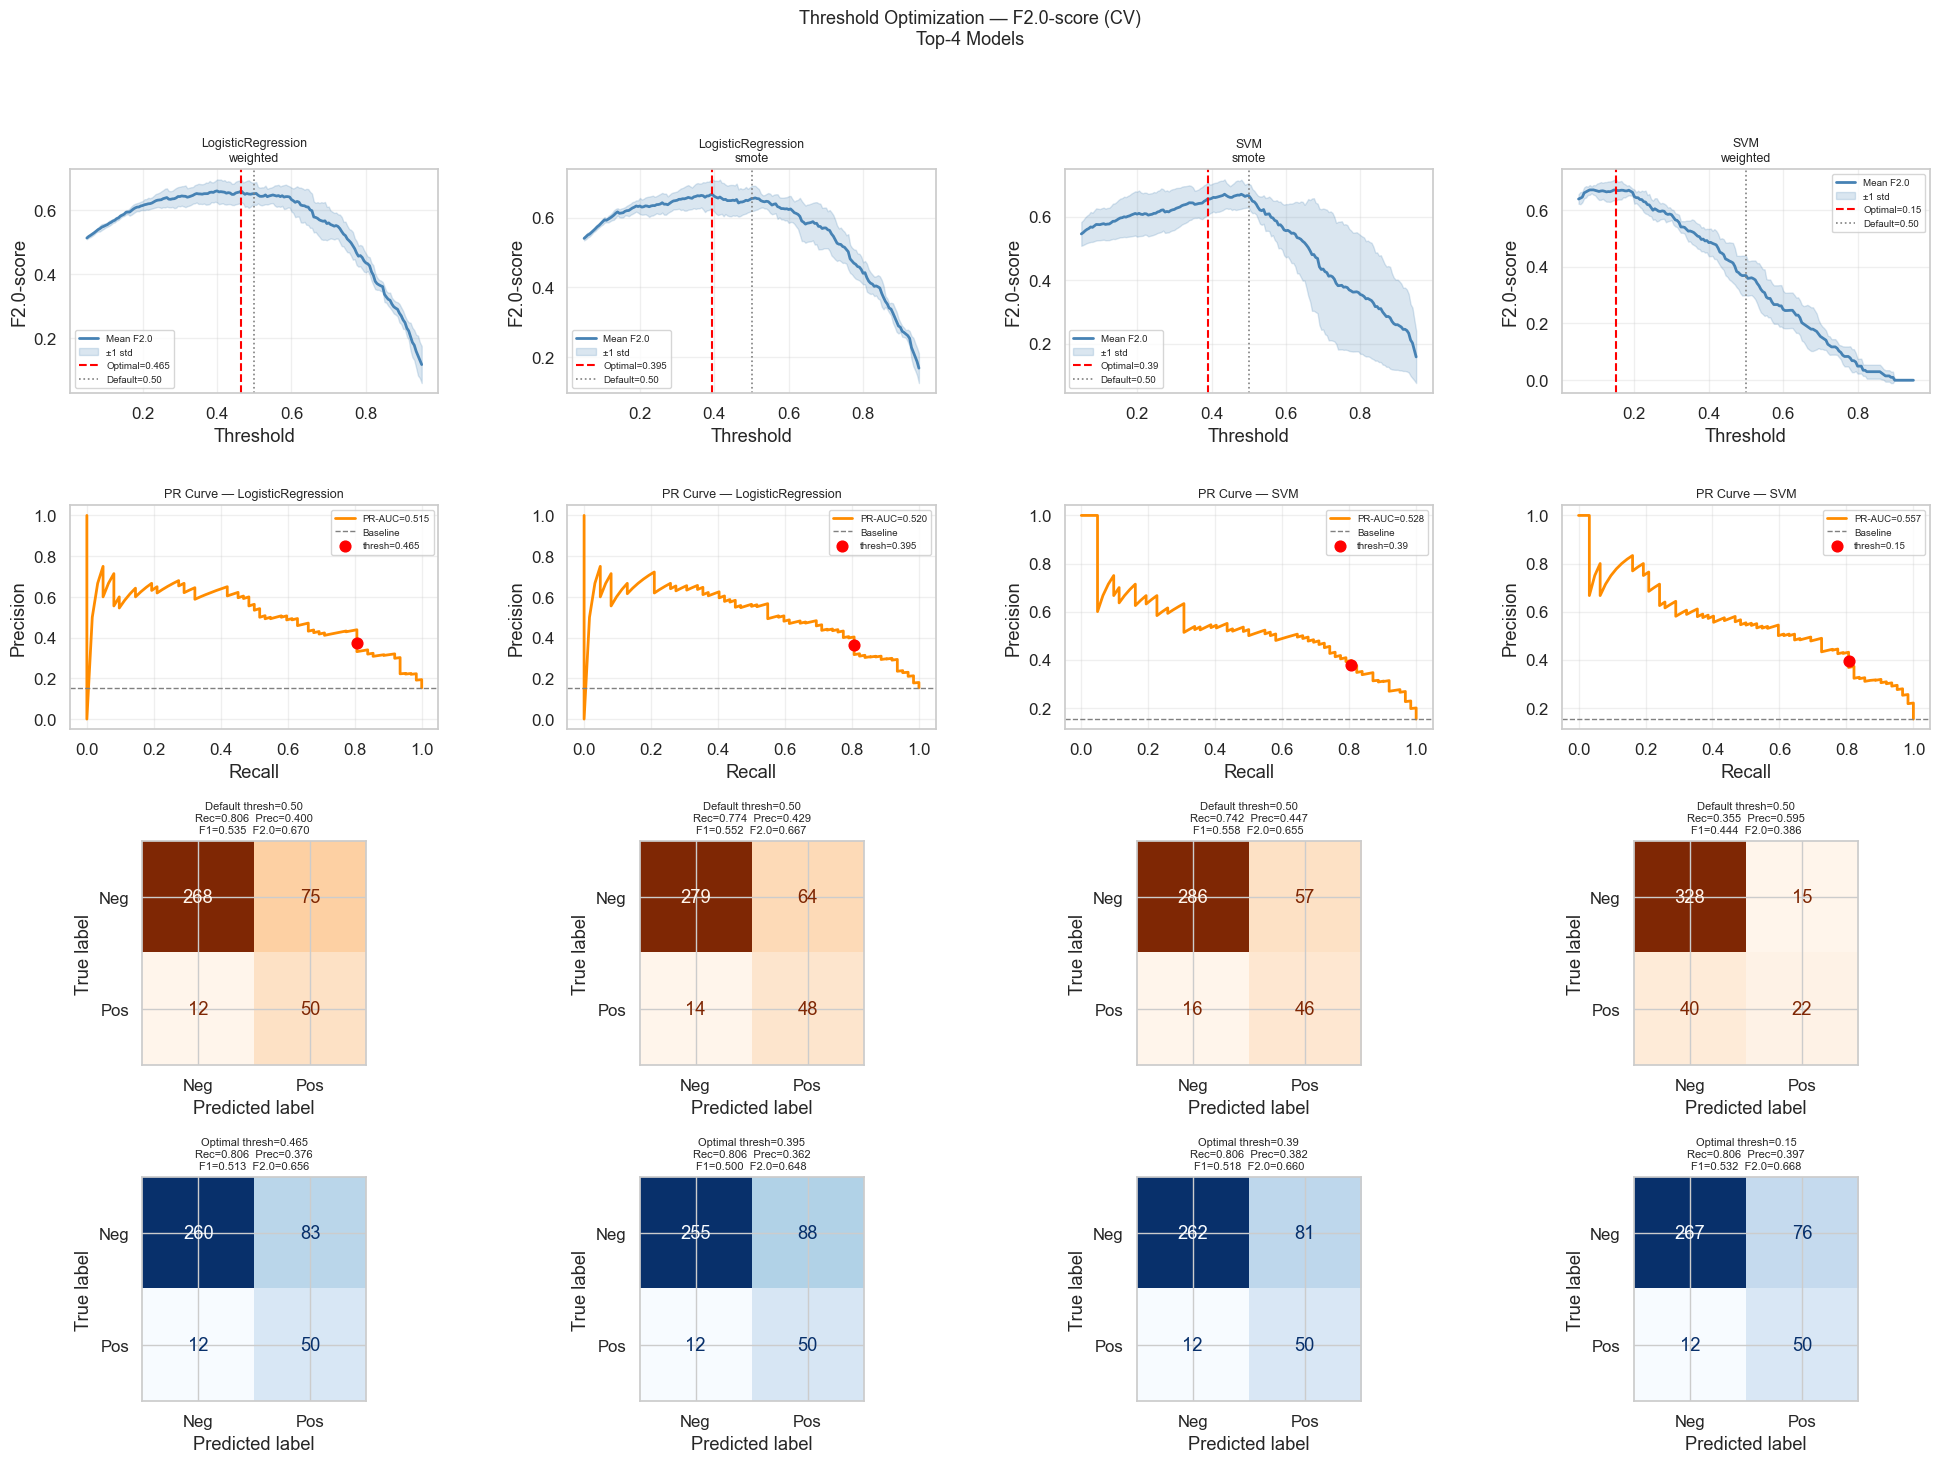

In [67]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    precision_recall_curve, fbeta_score, recall_score, precision_score,
    f1_score, roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, matthews_corrcoef, balanced_accuracy_score,
    ConfusionMatrixDisplay
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


top3_names = overfit_df.head(4)["Model"].tolist()
print("Топ-4 моделі:", top3_names)


def compute_all_metrics(y_true, y_pred, y_proba, beta=2.0):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return {
        "recall":       round(recall_score(y_true, y_pred, zero_division=0), 4),
        "precision":    round(precision_score(y_true, y_pred, zero_division=0), 4),
        "f1":           round(f1_score(y_true, y_pred, zero_division=0), 4),
        f"f{beta}":     round(fbeta_score(y_true, y_pred, beta=beta, zero_division=0), 4),
        "f2":           round(fbeta_score(y_true, y_pred, beta=2.0, zero_division=0), 4),
        "roc_auc":      round(roc_auc_score(y_true, y_proba), 4),
        "pr_auc":       round(average_precision_score(y_true, y_proba), 4),
        "mcc":          round(matthews_corrcoef(y_true, y_pred), 4),
        "balanced_acc": round(balanced_accuracy_score(y_true, y_pred), 4),
        "specificity":  round(specificity, 4),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
    }


def find_optimal_threshold_cv(pipeline, X, y, beta=2.0, n_splits=5, thresholds_grid=None):
    if thresholds_grid is None:
        thresholds_grid = np.linspace(0.05, 0.95, 181)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []
    optimal_thresholds = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        from sklearn.base import clone
        pipe_fold = clone(pipeline)
        pipe_fold.fit(X_tr, y_tr)

        y_proba_val = pipe_fold.predict_proba(X_val)[:, 1]

        best_fbeta, best_thresh = -1, 0.5
        fbeta_scores = []

        for thresh in thresholds_grid:
            y_pred_thresh = (y_proba_val >= thresh).astype(int)
            fb = fbeta_score(y_val, y_pred_thresh, beta=beta, zero_division=0)
            fbeta_scores.append(fb)
            if fb > best_fbeta:
                best_fbeta = fb
                best_thresh = thresh

        optimal_thresholds.append(best_thresh)
        y_pred_opt = (y_proba_val >= best_thresh).astype(int)
        metrics = compute_all_metrics(y_val, y_pred_opt, y_proba_val, beta=beta)

        fold_results.append({
            "fold":        fold + 1,
            "threshold":   round(best_thresh, 4),
            **metrics,
            "fbeta_curve": fbeta_scores,
        })

    optimal_thresholds = np.array(optimal_thresholds)
    threshold_stats = {
        "mean":   round(float(np.mean(optimal_thresholds)), 4),
        "median": round(float(np.median(optimal_thresholds)), 4),
        "std":    round(float(np.std(optimal_thresholds)), 4),
        "min":    round(float(np.min(optimal_thresholds)), 4),
        "max":    round(float(np.max(optimal_thresholds)), 4),
    }

    return threshold_stats["median"], fold_results, threshold_stats


BETA = 2.0
threshold_results = {}

CV_METRIC_COLS = ["threshold", "recall", "precision", "f1", f"f{BETA}",
                  "f2", "roc_auc", "pr_auc", "mcc", "balanced_acc",
                  "specificity", "tp", "fp", "tn", "fn"]

for name in top3_names:
    print(f"\n{'='*70}")
    print(f"  МОДЕЛЬ: {name}")
    print(f"{'='*70}")

    pipe = best_pipelines[name]

    best_thresh, fold_results, stats = find_optimal_threshold_cv(
        pipeline=pipe, X=X_train, y=y_train, beta=BETA, n_splits=5,
    )

    cv_df = pd.DataFrame(fold_results)[CV_METRIC_COLS]

    numeric_cols = [c for c in CV_METRIC_COLS if c != "threshold"]
    mean_row = {c: round(cv_df[c].mean(), 4) for c in numeric_cols}
    std_row  = {c: round(cv_df[c].std(), 4)  for c in numeric_cols}
    mean_row["threshold"] = f"{stats['mean']} ± {stats['std']}"
    std_row["threshold"]  = "(std)"

    cv_display = pd.concat([
        cv_df,
        pd.DataFrame([{**mean_row, **{"fold": "mean"}}]),
    ], ignore_index=True).fillna("")

    print(f"\n CV по фолдам (F{BETA}-оптимальний threshold):")
    print(cv_display.to_string(index=False))
    print(f"\n Статистика threshold: {stats}")
    print(f"→  Обраний threshold (медіана): {best_thresh}")

    pipe.fit(X_train, y_train)
    y_proba_test = pipe.predict_proba(X_test)[:, 1]

    y_pred_default = (y_proba_test >= 0.50).astype(int)
    y_pred_optimal = (y_proba_test >= best_thresh).astype(int)

    m_default = compute_all_metrics(y_test, y_pred_default, y_proba_test, beta=BETA)
    m_optimal = compute_all_metrics(y_test, y_pred_optimal, y_proba_test, beta=BETA)

    threshold_results[name] = {
        "best_threshold":  best_thresh,
        "fold_results":    fold_results,
        "stats":           stats,
        "test_default":    m_default,
        "test_optimal":    m_optimal,
        "y_proba_test":    y_proba_test,
        "y_pred_default":  y_pred_default,
        "y_pred_optimal":  y_pred_optimal,
    }

    print(f"\n TEST SET — порівняння метрик:")
    cmp_df = pd.DataFrame({
        "Metric":        list(m_default.keys()),
        "Default (0.50)": list(m_default.values()),
        f"Optimal ({best_thresh})": list(m_optimal.values()),
        "Delta":         [round(m_optimal[k] - m_default[k], 4)
                          if isinstance(m_optimal[k], float) else "—"
                          for k in m_default],
    })
    print(cmp_df.to_string(index=False))

    print(f"\n Classification Report (optimal threshold={best_thresh}):")
    print(classification_report(y_test, y_pred_optimal, zero_division=0))

print(f"\n{'='*70}")
print("ЗВЕДЕНА ТАБЛИЦЯ TEST — дефолт 0.5 vs оптимальний threshold")
print(f"{'='*70}")

summary_rows = []
for name in top3_names:
    res = threshold_results[name]
    for label, metrics in [("default_0.50", res["test_default"]),
                            (f"optimal_{res['best_threshold']}", res["test_optimal"])]:
        summary_rows.append({"Model": name, "Threshold": label, **{
            k: v for k, v in metrics.items()
            if k not in ("tp", "fp", "tn", "fn")
        }})

summary_thresh_df = pd.DataFrame(summary_rows)
print(summary_thresh_df.to_string(index=False))

thresholds_grid = np.linspace(0.05, 0.95, 181)
n = len(top3_names)

fig = plt.figure(figsize=(6 * n, 16))
gs = gridspec.GridSpec(4, n, figure=fig, hspace=0.5, wspace=0.35)

for col, name in enumerate(top3_names):
    res = threshold_results[name]
    opt_thresh = res["best_threshold"]

    ax_curve = fig.add_subplot(gs[0, col])
    all_curves = np.array([f["fbeta_curve"] for f in res["fold_results"]])
    mean_c = all_curves.mean(axis=0)
    std_c  = all_curves.std(axis=0)

    ax_curve.plot(thresholds_grid, mean_c, color="steelblue", lw=2, label=f"Mean F{BETA}")
    ax_curve.fill_between(thresholds_grid, mean_c - std_c, mean_c + std_c,
                          alpha=0.2, color="steelblue", label="±1 std")
    ax_curve.axvline(opt_thresh, color="red",  linestyle="--", lw=1.5, label=f"Optimal={opt_thresh}")
    ax_curve.axvline(0.50,       color="gray", linestyle=":",  lw=1.2, label="Default=0.50")
    ax_curve.set_title(name.replace("_", "\n"), fontsize=9)
    ax_curve.set_xlabel("Threshold")
    ax_curve.set_ylabel(f"F{BETA}-score")
    ax_curve.legend(fontsize=7)
    ax_curve.grid(True, alpha=0.3)

    ax_pr = fig.add_subplot(gs[1, col])
    prec, rec, thr = precision_recall_curve(y_test, res["y_proba_test"])
    pr_auc_val = average_precision_score(y_test, res["y_proba_test"])

    ax_pr.plot(rec, prec, color="darkorange", lw=2, label=f"PR-AUC={pr_auc_val:.3f}")
    ax_pr.axhline(y_test.mean(), color="gray", linestyle="--", lw=1, label="Baseline")

    idx_opt = np.argmin(np.abs(thr - opt_thresh)) if len(thr) > 0 else None
    if idx_opt is not None:
        ax_pr.scatter(rec[idx_opt], prec[idx_opt], color="red", zorder=5,
                      label=f"thresh={opt_thresh}", s=60)

    ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision")
    ax_pr.set_title(f"PR Curve — {name.split('_')[0]}", fontsize=9)
    ax_pr.legend(fontsize=7)
    ax_pr.grid(True, alpha=0.3)

    ax_cm_def = fig.add_subplot(gs[2, col])
    cm_def = confusion_matrix(y_test, res["y_pred_default"])
    disp_def = ConfusionMatrixDisplay(cm_def, display_labels=["Neg", "Pos"])
    disp_def.plot(ax=ax_cm_def, colorbar=False, cmap="Oranges")
    m_def = res["test_default"]
    ax_cm_def.set_title(
        f"Default thresh=0.50\n"
        f"Rec={m_def['recall']:.3f}  Prec={m_def['precision']:.3f}\n"
        f"F1={m_def['f1']:.3f}  F{BETA}={m_def[f'f{BETA}']:.3f}",
        fontsize=8
    )

    ax_cm_opt = fig.add_subplot(gs[3, col])
    cm_opt = confusion_matrix(y_test, res["y_pred_optimal"])
    disp_opt = ConfusionMatrixDisplay(cm_opt, display_labels=["Neg", "Pos"])
    disp_opt.plot(ax=ax_cm_opt, colorbar=False, cmap="Blues")
    m_opt = res["test_optimal"]
    ax_cm_opt.set_title(
        f"Optimal thresh={opt_thresh}\n"
        f"Rec={m_opt['recall']:.3f}  Prec={m_opt['precision']:.3f}\n"
        f"F1={m_opt['f1']:.3f}  F{BETA}={m_opt[f'f{BETA}']:.3f}",
        fontsize=8
    )

fig.suptitle(f"Threshold Optimization — F{BETA}-score (CV)\nTop-{n} Models", fontsize=13)
plt.show()